# SAE : Mise en oeuvre d'un processus de data mining

#### - Détection des annonces susceptibles d'entraîner une modification de la base vectorielle de l'IGN

## Groupe Kaggle : The MiniBG


## Etudiants :

- Mohamed DIALLO  

- Gauthier RAIMBAULT

- Aymeric AYHAN

## Objectif et rendu

#### L’objectif est de mettre au point le meilleur système pour distinguer automatiquement les annonces pertinentes des annonces hors spécifications parmi celles publiées dans le bulletin des annonces de marché public (BOAMP).

Après avoir pris connaissance de la base de données, nous avons transformé les fichiers d'entraînement et de test JSON en fichiers CSV pour avoir une vision des variables en colonnes et pour la soumission du fichier de test au niveau de Kaggle. Notre but dans un premier temps est d'identifier les variables inutiles qui pourraient potentiellement ne pas avoir d'impact sur la prévision. Ensuite, nous testerons la racinisation des variables textuelles, puis les vectoriserons pour tester quelques classifieurs comme le KNN, la régression logistique, l'arbre de décision et la forêt aléatoire.

# Analyse exploratoire des données

###  La répartition du type des colonnes

In [ ]:
import pandas as pd
train_df = pd.read_excel("data_train.xlsx")
train_df.dtypes.value_counts()

object     22
int64       3
float64     3
Name: count, dtype: int64

<Axes: ylabel='count'>

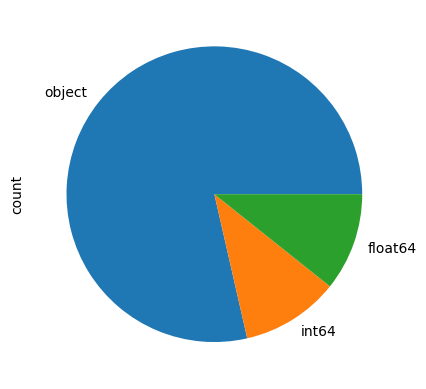

In [ ]:
train_df.dtypes.value_counts().plot.pie()

On constate qu'il y a très peu de champs à valeur numérique. La grande majorité des données à traiter sont des données de type texte.

### Analyser les valeurs nulles

Nous avons voulu voir s'il y avait des valeurs nulles dans notre jeu de données afin de nous aider à décider si nous devions garder ou non certaines colonnes pour l'entraînement du modèle.

In [ ]:
import numpy as np
#Formater les valeurs nulles en NA
train_df.replace("None", np.nan, inplace=True)
train_df.replace("", np.nan, inplace=True)

<Axes: >

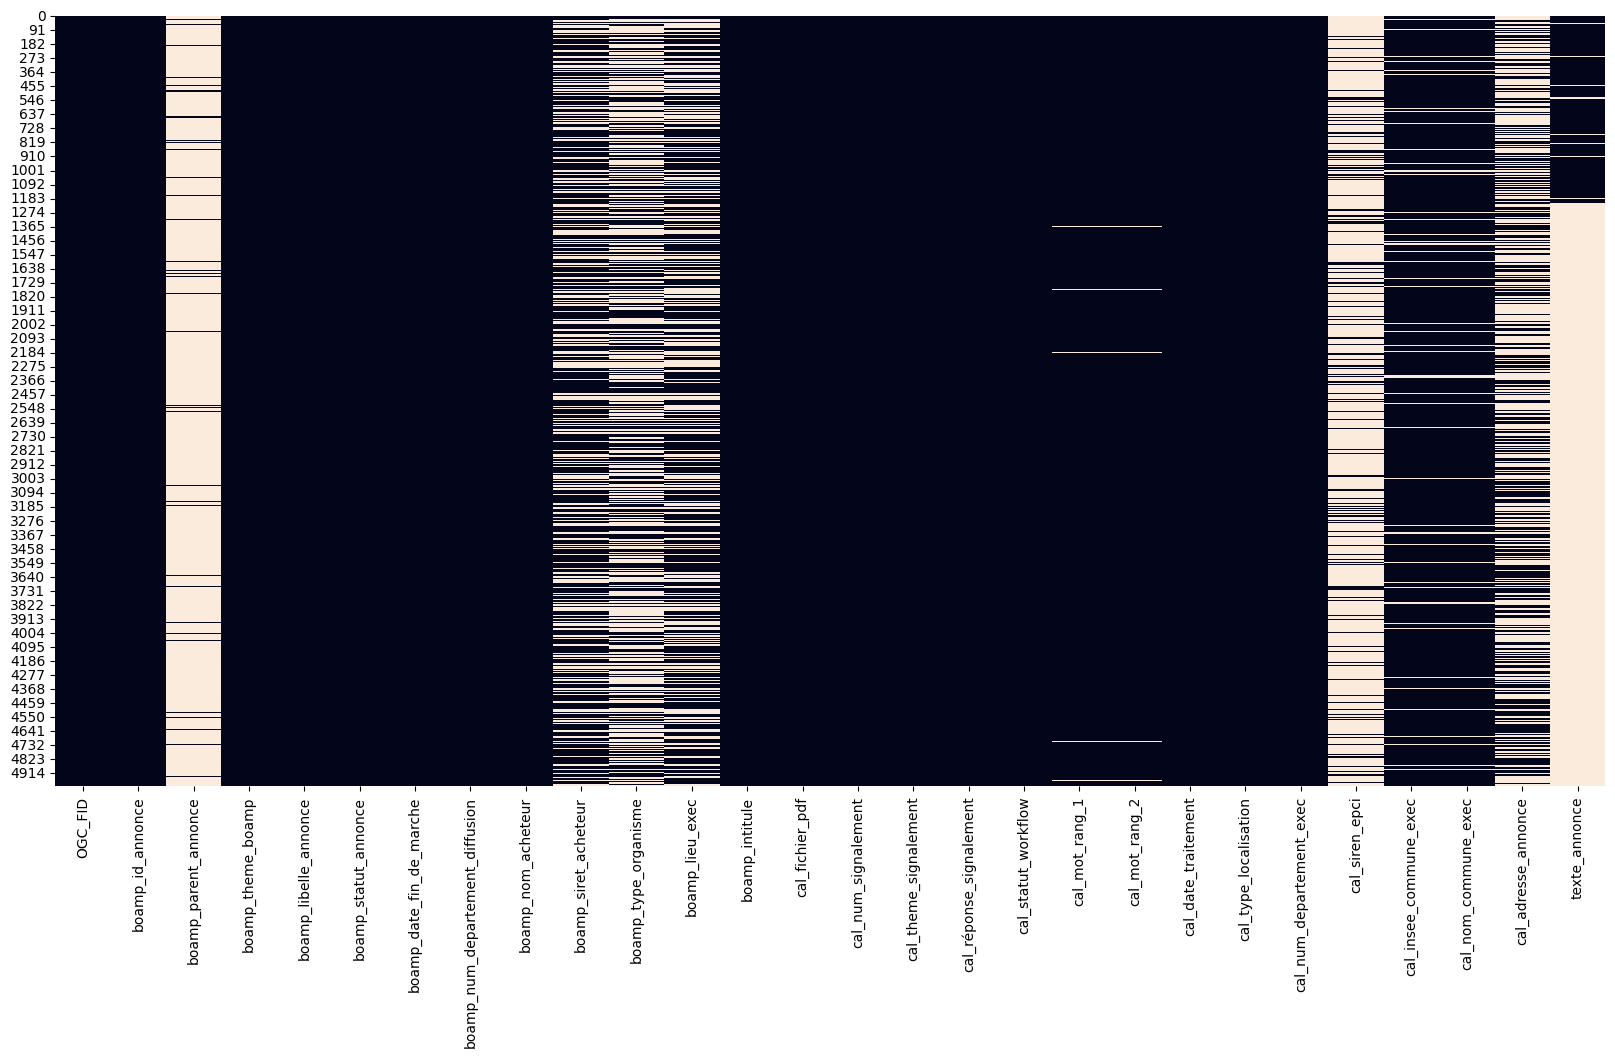

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

#Visualiser le dataframe et les valeurs nulles
plt.figure(figsize=(20,10))
sns.heatmap(train_df.isna(), cbar=False)

Ce graphique nous permet de visualiser facilement l'ensemble de nos données et de voir si les colonnes contiennent ou non des valeurs nulles.

In [ ]:
(train_df.isna().sum() / train_df.shape[0]).sort_values(ascending=True)

OGC_FID                            0.0000
cal_num_departement_exec           0.0000
cal_date_traitement                0.0000
cal_statut_workflow                0.0000
cal_réponse_signalement            0.0000
cal_theme_signalement              0.0000
cal_num_signalement                0.0000
boamp_intitule                     0.0000
cal_fichier_pdf                    0.0000
boamp_num_departement_diffusion    0.0000
boamp_id_annonce                   0.0000
boamp_date_fin_de_marche           0.0000
boamp_statut_annonce               0.0000
boamp_libelle_annonce              0.0000
boamp_theme_boamp                  0.0000
boamp_nom_acheteur                 0.0000
cal_type_localisation              0.0002
cal_mot_rang_1                     0.0024
cal_mot_rang_2                     0.0024
cal_nom_commune_exec               0.0596
cal_insee_commune_exec             0.0596
boamp_siret_acheteur               0.3396
boamp_lieu_exec                    0.3812
cal_adresse_annonce               

### On peut observer que les colonnes qui contiennent un certain nombre de valeurs nulles sont :

- boamp_siret_acheteur (33%)              
- boamp_lieu_exec (38%)                   
- cal_adresse_annonce (52%)               
- boamp_type_organisme (52%)              
- texte_annonce (76%)                     
- cal_siren_epci (82%)                    
- boamp_parent_annonce (95%)              

## Importation du fichier d'entrainement et suppression des variables inutiles à la prévision

In [ ]:
import pandas as pd

train_df = pd.read_excel("data_train.xlsx")
#suppresion des variables jugées inutiles
train_df = train_df.drop(['boamp_id_annonce', 'boamp_parent_annonce', 'cal_fichier_pdf', 'cal_num_signalement','boamp_siret_acheteur','cal_adresse_annonce','boamp_lieu_exec','cal_type_localisation','cal_statut_workflow','boamp_type_organisme'], axis=1)
train_df.head()

,OGC_FID,boamp_theme_boamp,boamp_libelle_annonce,boamp_statut_annonce,boamp_date_fin_de_marche,boamp_num_departement_diffusion,boamp_nom_acheteur,boamp_intitule,cal_theme_signalement,cal_réponse_signalement,cal_mot_rang_1,cal_mot_rang_2,cal_date_traitement,cal_num_departement_exec,cal_siren_epci,cal_insee_commune_exec,cal_nom_commune_exec,texte_annonce
0,9723,Espaces verts,Avis de marché,INITIAL,2024-02-02,31,TOULOUSE METROPOLE,Travaux d'aménagement de l'île du Ramier à Tou...,Route,Pris en compte,travaux,aménagement,2023-12-22,31,243100518.0,31555.0,TOULOUSE,Avis n° 23-177335\n \nAttention : les informa...
1,10502,Station d'épuration (travaux),Avis de marché,INITIAL,2024-08-08,09,Syndicat Mixte Départemental de l'Eau et de l'...,Travaux de construction de la nouvelle station...,Points d'intérêt,Pris en compte,nouvelle,station,2024-05-30,9,NaN,9332.0,VERNIOLLE,1/3\nAvis de marché\nAttention : les informat...
2,10900,Voirie et réseaux divers,Rectificatif,RECTIFICATIF,2024-08-23,33,Bordeaux Métropole,"Aménagement de la place de la Renaudel, rues ...",Route,Pris en compte,aménagement,place,2024-08-14,33,243300316.0,33063.0,BORDEAUX,1/1\nAvis rectificatif\nAttention : les infor...
3,779,"Prestations de services, Délégation de service...",Avis de marché,INITIAL,2024-04-16,75,Ville de Paris,Rénovation du parc de stationnement St Martin ...,Points d'intérêt,Rejete (hors specs),transformation,parc,2023-12-29,75,NaN,75056.0,PARIS,Avis n° 23-179664\n \nAttention : les informa...
4,5614,Génie civil,Avis de marché,INITIAL,2024-07-11,43,Département de la Haute-Loire,Rd12 - Reconstruction Du Pont Sur La Loire A B...,Route,Pris en compte,reconstruction,pont,2024-06-14,43,NaN,43020.0,BAS EN BASSET,1/2\nAvis de marché\nAttention : les informat...


## Importation du fichier de test et suppression des variables inutiles à la prévision

In [ ]:
import pandas as pd

test_df = pd.read_excel("data_test.xlsx")
#suppresion des variables jugées inutiles
test_df = test_df.drop(['boamp_id_annonce', 'boamp_parent_annonce', 'cal_fichier_pdf', 'cal_num_signalement','boamp_siret_acheteur','cal_adresse_annonce'], axis=1)
test_df.head()

,Unnamed: 0,OGC_FID,boamp_theme_boamp,boamp_libelle_annonce,boamp_statut_annonce,boamp_date_fin_de_marche,boamp_num_departement_diffusion,boamp_nom_acheteur,boamp_type_organisme,boamp_lieu_exec,...,cal_statut_workflow,cal_mot_rang_1,cal_mot_rang_2,cal_date_traitement,cal_type_localisation,cal_num_departement_exec,cal_siren_epci,cal_insee_commune_exec,cal_nom_commune_exec,texte_annonce
0,0,9618,Voirie et réseaux divers,Avis de marché,INITIAL,2023-12-15,33,COBAS,CA BASSIN D'ARCACHON SUD (COBAS),Le Teich 33470 - Le Teich,...,50-signalement posté,création,piste,2023-11-17,loc_intitule_adresse,33,243300563.0,33527.0,LE TEICH,Avis n° 23-161305\n \nAttention : les informa...
1,1,4428,"Carrelage, Charpente, Chauffage (travaux), Clo...",Avis de marché,INITIAL,2024-01-23,25,Mairie de Burgille,COMMUNE DE BURGILLE,25170 Burgille,...,50-signalement posté,réhabilitation,mairie,2023-11-22,loc_orga_commune,25,NaN,25101.0,BURGILLE,Avis n° 23-163361\n \nAttention : les informa...
2,2,10787,Voirie,Avis de marché,INITIAL,2024-09-09,82,Mairie de Caylus,NaN,82160 - Caylus,...,50-signalement posté,aménagement,secteur,2024-07-17,loc_acheteur_commune,82,NaN,82038.0,CAYLUS,1/2\nAvis de marché\nAttention : les informat...
3,3,4655,Bâtiment,Avis de marché,INITIAL,2024-02-06,38,Communauté de communes de l'Oisans,COMMUNAUTE DE COMMUNES DE L'OISANS,Bourg d'Oisans 38520 - Le Bourg d'Oisans,...,50-signalement posté,construction,maison,2023-12-29,loc_intitule_poi,38,243800745.0,38052.0,LE BOURG D OISANS,Avis n° 23-180649\n \nAttention : les informa...
4,4,3843,"Fontainerie, Terrassement",Rectificatif,RECTIFICATIF,2024-12-05,"92,75,95,94,15,91,77,76,46",Mairie,VILLE,NaN,...,50-signalement posté,réaménagement,jardin,2024-10-21,loc_intitule_commune,92,NaN,92077.0,VILLE D AVRAY,1/1\nAvis rectificatif\nAttention : les infor...


Nous avons effectué une analyse exploratoire des données au niveau de trois variables : le libellé de l'annonce, le thème du signalement et la réponse du signalement, dans le but d'observer quelles sont les annonces qui reviennent le plus souvent ainsi que les thèmes de signalement, puis la répartition des annonces en pourcentage qui sont prises en compte ou rejetées.

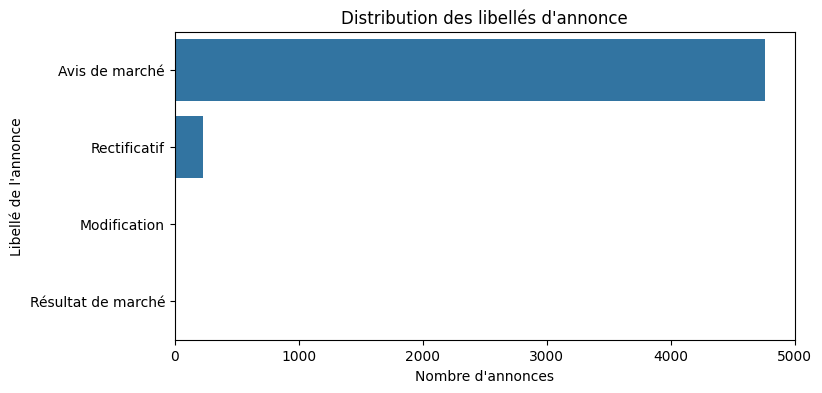

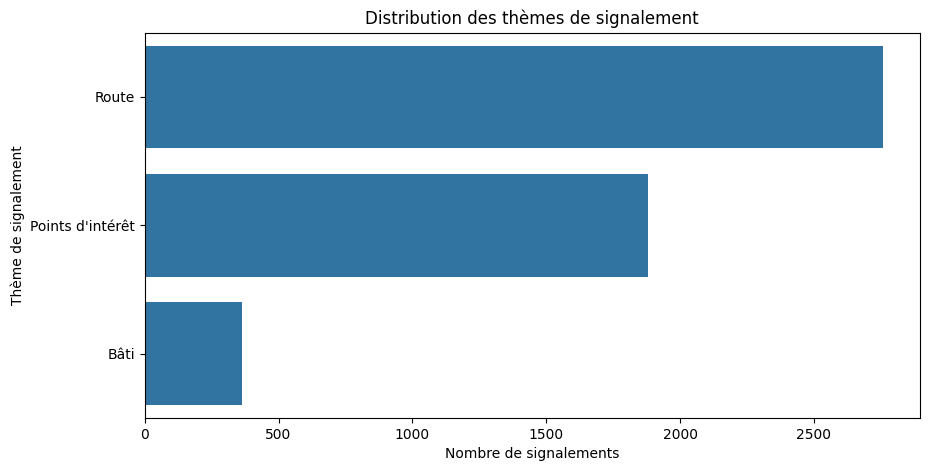

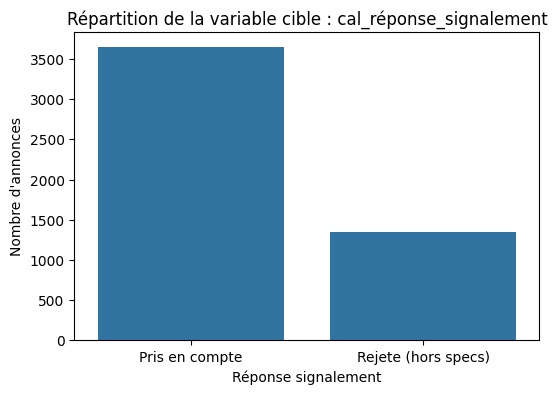

Répartition en pourcentage de la variable cible :
 cal_réponse_signalement
Pris en compte         73.02
Rejete (hors specs)    26.98
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns



## Distribution de boamp_libelle_annonce
plt.figure(figsize=(8, 4))
sns.countplot(y=train_df['boamp_libelle_annonce'], order=train_df['boamp_libelle_annonce'].value_counts().index)
plt.title('Distribution des libellés d\'annonce')
plt.xlabel("Nombre d'annonces")
plt.ylabel("Libellé de l'annonce")
plt.show()

## Distribution de cal_theme_signalement
plt.figure(figsize=(10, 5))
sns.countplot(y=train_df['cal_theme_signalement'], order=train_df['cal_theme_signalement'].value_counts().index)
plt.title('Distribution des thèmes de signalement')
plt.xlabel("Nombre de signalements")
plt.ylabel("Thème de signalement")
plt.show()

# 2. Étude de la variable cible : cal_réponse_signalement
## Distribution des classes dans cal_réponse_signalement
plt.figure(figsize=(6, 4))
sns.countplot(x=train_df['cal_réponse_signalement'])
plt.title('Répartition de la variable cible : cal_réponse_signalement')
plt.xlabel("Réponse signalement")
plt.ylabel("Nombre d'annonces")
plt.show()

# Calculer la proportion de chaque classe dans cal_réponse_signalement
class_distribution = train_df['cal_réponse_signalement'].value_counts(normalize=True) * 100
print("Répartition en pourcentage de la variable cible :\n", class_distribution)


## Préparation des variables Textuelles

Au niveau de la préparation des variables textuelles, nous avons effectué quelques étapes de transformation de données nécessaires pour l'optimisation des modèles que nous testerons.

Nous avons le nettoyage des textes avec suppression des caractères spéciaux, conversion en minuscules et suppression des stopwords. Ensuite, la racinisation pour réduire les mots à leurs formes racinaires, puis la vectorisation des textes pour transformer chaque colonne textuelle en vecteurs TF-IDF, avec un maximum de 300 mots et bigrammes les plus fréquents pour une optimisation de la puissance de calcul.

Les deux variables majeures choisies pour la racinisation et la vectorisation ont été sélectionnées en fonction de là où la majorité des informations utiles à la prédiction sont stockées. Nous avons identifié qu'au niveau de la variable 'texte annonce', nous avons toutes les informations concernant les annonces, et au niveau de la variable 'boamp_intitule', nous avons l'intitulé des annonces, c'est-à-dire la description par annonce.

## Pré-Traitement du texte avec la racinisation sur les données d'entrainement

In [ ]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk

# Assurez-vous de télécharger les stopwords si nécessaire
nltk.download('stopwords')

# Charger les données et supprimer les colonnes inutiles
train_df = pd.read_excel("data_train.xlsx")

# Définir les colonnes textuelles à traiter
text_columns = ['boamp_intitule', 'texte_annonce']
stemmer = SnowballStemmer('french')

# Fonction de nettoyage des textes
def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'[^\w\s]', ' ', text)  # Retirer la ponctuation
    words = text.lower().split()
    words = [word for word in words if word not in stopwords.words('french')]
    return ' '.join(words)

# Fonction de racinisation des textes
def stem_text(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

# Appliquer le nettoyage et la racinisation aux colonnes textuelles
for col in text_columns:
    train_df[col] = train_df[col].apply(lambda x: stem_text(clean_text(x)))

# Vectorisation des colonnes textuelles
vectorized_dfs = {}
for col in text_columns:
    vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
    vectorized_df = pd.DataFrame(vectorizer.fit_transform(train_df[col]).toarray(),
                                 columns=[f"{col}_{feat}" for feat in vectorizer.get_feature_names_out()])
    vectorized_dfs[col] = vectorized_df

# Concaténer les colonnes vectorisées pour obtenir le DataFrame final
final_df = pd.concat(list(vectorized_dfs.values()), axis=1)

# Affichage d'un échantillon des données finales
print(final_df.head())


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\diall\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   boamp_intitule_01  boamp_intitule_10  boamp_intitule_11  boamp_intitule_12  \
0                0.0                0.0                0.0                0.0   
1                0.0                0.0                0.0                0.0   
2                0.0                0.0                0.0                0.0   
3                0.0                0.0                0.0                0.0   
4                0.0                0.0                0.0                0.0   

   boamp_intitule_13  boamp_intitule_14  boamp_intitule_16  boamp_intitule_17  \
0                0.0                0.0                0.0                0.0   
1                0.0                0.0                0.0                0.0   
2                0.0                0.0                0.0                0.0   
3                0.0                0.0                0.0                0.0   
4                0.0                0.0                0.0                0.0   

   boamp_intitule_19  boam

#### Enregistrement du finalDF dans un fichier csv

In [ ]:
# Enregistrer le DataFrame final en fichier CSV pour un usage futur
final_df.to_csv("final_dataframe.csv", index=False)

Après avoir racinisé et vectorisé les variables textuelles et réduit les données à 500 pour obtenir les données les plus fréquentes au niveau des variables sélectionnées, nous allons dans un premier temps évaluer différents classifieurs afin d'identifier le meilleur modèle.

## Classification et évaluation des modèles sur les données d'entrainement

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Séparation des données (caractéristiques et cible)
X = final_df
y = train_df['cal_réponse_signalement']  # La variable cible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Création et entraînement des modèles
models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Bernoulli Naive Bayes': BernoulliNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'K Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

# Évaluation des modèles
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calcul des métriques
    accuracy = accuracy_score(y_test, y_pred)
    weighted_f1 = f1_score(y_test, y_pred, average='weighted', pos_label="Pris en compte")
    report = classification_report(y_test, y_pred, zero_division=0)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)

    # Affichage des résultats
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Weighted F1 Score: {weighted_f1:.2f}")
    print(f"Classification Report:\n{report}")
    print(f"Cross-Validation Mean Accuracy: {cv_scores.mean():.2f}")
    print('-' * 50)

C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'Pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


Model: Multinomial Naive Bayes
Accuracy: 0.76
Weighted F1 Score: 0.70
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.77      0.97      0.86       741
Rejete (hors specs)       0.63      0.16      0.26       259

           accuracy                           0.76      1000
          macro avg       0.70      0.56      0.56      1000
       weighted avg       0.73      0.76      0.70      1000

Cross-Validation Mean Accuracy: 0.73
--------------------------------------------------


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'Pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


Model: Bernoulli Naive Bayes
Accuracy: 0.66
Weighted F1 Score: 0.68
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.82      0.69      0.75       741
Rejete (hors specs)       0.39      0.58      0.47       259

           accuracy                           0.66      1000
          macro avg       0.61      0.63      0.61      1000
       weighted avg       0.71      0.66      0.68      1000

Cross-Validation Mean Accuracy: 0.51
--------------------------------------------------


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'Pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


...

Model: K Nearest Neighbors
Accuracy: 0.73
Weighted F1 Score: 0.71
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.78      0.87      0.83       741
Rejete (hors specs)       0.46      0.32      0.38       259

           accuracy                           0.73      1000
          macro avg       0.62      0.59      0.60      1000
       weighted avg       0.70      0.73      0.71      1000

Cross-Validation Mean Accuracy: 0.70
--------------------------------------------------


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'Pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


Model: Decision Tree
Accuracy: 0.69
Weighted F1 Score: 0.69
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.80      0.77      0.79       741
Rejete (hors specs)       0.41      0.44      0.42       259

           accuracy                           0.69      1000
          macro avg       0.60      0.61      0.61      1000
       weighted avg       0.70      0.69      0.69      1000

Cross-Validation Mean Accuracy: 0.65
--------------------------------------------------


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'Pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


Model: Random Forest
Accuracy: 0.75
Weighted F1 Score: 0.71
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.78      0.93      0.85       741
Rejete (hors specs)       0.54      0.23      0.32       259

           accuracy                           0.75      1000
          macro avg       0.66      0.58      0.58      1000
       weighted avg       0.71      0.75      0.71      1000

Cross-Validation Mean Accuracy: 0.72
--------------------------------------------------


Après avoir effectué la racinisation puis la vectorisation tout en réduisant les données à 500 caractères, les trois meilleurs classifieurs sont : le modèle de régression logistique avec 0,73 soit 73%, et les modèles KNN et la forêt aléatoire avec 0,71 soit 71% au niveau de la métrique 'weighted F1 score', qui applique l'F1-score pondéré sur les prédictions en tenant compte des classes déséquilibrées.

## Optimisation de la  vectorisation au niveau des données d'entrainement

Nous allons éssayer de trouver le meilleurs hyperparamètres au niveau de la réduction des dimensions puis ensuite tester sur les classifieurs . cette étape nous permettra d'identifier si l'optimisation de cet hyperparamètre a un impact sur les classifieurs sachant qu'une réduction des caractéristiques(données) à 500 est déja établie et cette étape nous à permis de recupérer les informations les plus frequentes au niveau des variables selectionnées . Ensuite la reduction des dimensions nous permettra de recupérer les composantes principales des données pour obtenir les données les plus utiles .  

#### Choisir la Meilleure Valeur de n_components et le tester sur les différents classifieurs




Meilleure valeur pour n_components : 300 avec variance cumulée : 0.8936


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'Pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


Model: Multinomial Naive Bayes
Accuracy: 0.74
Weighted F1 Score: 0.63
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.74      1.00      0.85       741
Rejete (hors specs)       0.00      0.00      0.00       259

           accuracy                           0.74      1000
          macro avg       0.37      0.50      0.43      1000
       weighted avg       0.55      0.74      0.63      1000

Cross-Validation Mean Accuracy: 0.73
--------------------------------------------------


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'Pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


Model: Bernoulli Naive Bayes
Accuracy: 0.74
Weighted F1 Score: 0.64
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.74      0.99      0.85       741
Rejete (hors specs)       0.36      0.02      0.03       259

           accuracy                           0.74      1000
          macro avg       0.55      0.50      0.44      1000
       weighted avg       0.64      0.74      0.64      1000

Cross-Validation Mean Accuracy: 0.72
--------------------------------------------------


...

Model: K Nearest Neighbors
Accuracy: 0.70
Weighted F1 Score: 0.68
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.77      0.86      0.81       741
Rejete (hors specs)       0.39      0.26      0.31       259

           accuracy                           0.70      1000
          macro avg       0.58      0.56      0.56      1000
       weighted avg       0.67      0.70      0.68      1000

Cross-Validation Mean Accuracy: 0.70
--------------------------------------------------


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'Pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


Model: Decision Tree
Accuracy: 0.67
Weighted F1 Score: 0.68
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.79      0.76      0.77       741
Rejete (hors specs)       0.38      0.43      0.40       259

           accuracy                           0.67      1000
          macro avg       0.59      0.59      0.59      1000
       weighted avg       0.69      0.67      0.68      1000

Cross-Validation Mean Accuracy: 0.65
--------------------------------------------------


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'Pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


Model: Random Forest
Accuracy: 0.74
Weighted F1 Score: 0.65
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.75      0.97      0.85       741
Rejete (hors specs)       0.43      0.06      0.10       259

           accuracy                           0.74      1000
          macro avg       0.59      0.52      0.47      1000
       weighted avg       0.66      0.74      0.65      1000

Cross-Validation Mean Accuracy: 0.73
--------------------------------------------------


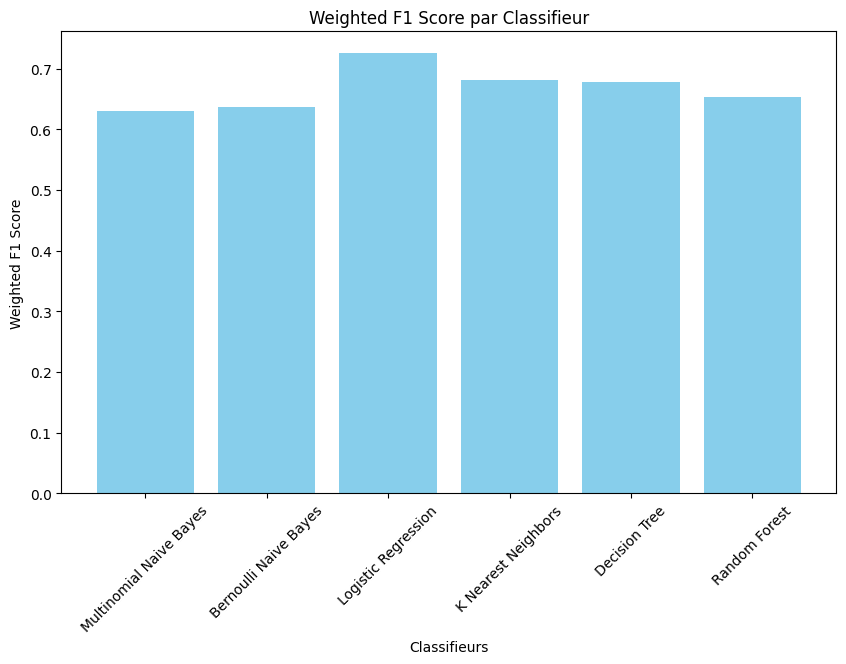

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Utiliser final_df, votre DataFrame vectorisé
X = final_df  # Les données vectorisées
y = train_df['cal_réponse_signalement']  # Variable cible

# Plage de valeurs pour n_components à tester
n_components_range = list(range(50, 301, 50))
variance_threshold = 0.85  # Objectif de variance cumulative souhaitée (ajustable entre 0.80 et 0.90)
best_n_components = None
best_explained_variance = 0

# Recherche du meilleur n_components pour capturer la variance désirée
for n_components in n_components_range:
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    X_reduced = svd.fit_transform(X)

    # Calcul de la variance cumulée
    cumulative_variance = svd.explained_variance_ratio_.sum()

    if cumulative_variance >= variance_threshold and cumulative_variance > best_explained_variance:
        best_n_components = n_components
        best_explained_variance = cumulative_variance

print(f"\nMeilleure valeur pour n_components : {best_n_components} avec variance cumulée : {best_explained_variance:.4f}")

# Appliquer TruncatedSVD avec le meilleur n_components
svd = TruncatedSVD(n_components=best_n_components, random_state=42)
X_reduced = svd.fit_transform(X)

# Normaliser les données après réduction avec MinMaxScaler pour éviter les valeurs négatives
scaler = MinMaxScaler()
X_reduced = scaler.fit_transform(X_reduced)
final_df_reduced = pd.DataFrame(X_reduced, columns=[f"svd_component_{i+1}" for i in range(best_n_components)])

# Séparation des données (caractéristiques réduites et cible)
X_train, X_test, y_train, y_test = train_test_split(final_df_reduced, y, test_size=0.2, random_state=42)

# Création des modèles de classification
models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Bernoulli Naive Bayes': BernoulliNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'K Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

# Liste pour stocker les résultats du weighted F1 score par modèle
f1_scores = []

# Évaluation des modèles avec les données réduites
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calcul des métriques
    accuracy = accuracy_score(y_test, y_pred)
    weighted_f1 = f1_score(y_test, y_pred, average='weighted',pos_label="Pris en compte")
    report = classification_report(y_test, y_pred, zero_division=0)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)

    # Enregistrer le weighted F1 score pour la visualisation
    f1_scores.append(weighted_f1)

    # Affichage des résultats
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Weighted F1 Score: {weighted_f1:.2f}")
    print(f"Classification Report:\n{report}")
    print(f"Cross-Validation Mean Accuracy: {cv_scores.mean():.2f}")
    print('-' * 50)

# Visualisation de l'évolution du weighted F1 score par classifieur
plt.figure(figsize=(10, 6))
plt.bar(models.keys(), f1_scores, color='skyblue')
plt.title('Weighted F1 Score par Classifieur')
plt.xlabel('Classifieurs')
plt.ylabel('Weighted F1 Score')
plt.xticks(rotation=45)
plt.show()


En ayant trouvé le meilleur hyperparamètre au niveau du n_components qui est de 300 et qui nous offre une variance cumulée à 0,89 %, combiné avec une réduction des données à 500 caractères, on constate qu'il n'y a pas d'impact significatif sur le modèle de la régression logistique car le 'weighted F1 score' reste inchangé. Néanmoins, on s'aperçoit qu'au niveau des autres classifieurs, il y a une baisse du 'weighted F1 score'.

## Analyse

Alors, après avoir effectué toutes ces étapes, nous nous sommes rendu compte que pour l'instant, notre meilleur modèle est la régression logistique avec 0,73 de 'weighted F1-score', tout en ayant comme pré-traitement la racinisation et la vectorisation de deux variables : 'boamp_intitule' et 'texte_annonce', avec une réduction des données 'max_features=500'.

Pour la suite, nous allons essayer de trouver les meilleurs hyperparamètres pour le modèle de régression logistique et tester avec les données vectorisées et réduites sans la combinaison avec la réduction des dimensions, car nous constatons que cette combinaison n'a pas d'impact significatif sur les classifieurs.




## Optimisation du modèle de regression logistique en utilisant les meilleurs hyperparamètres

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

# Utiliser final_df sans réduction de dimension comme ensemble de données
X = final_df  # Les données vectorisées sans réduction de dimension
y = train_df['cal_réponse_signalement']  # Variable cible

# Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Définition de l'espace des hyperparamètres pour la régression logistique
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Essai de différentes valeurs pour le paramètre de régularisation
    'solver': ['liblinear', 'lbfgs'],  # Différents solveurs possibles pour optimiser
    'penalty': ['l2'],  # 'l1' est disponible uniquement pour le solver 'liblinear'
    'max_iter': [100, 200, 500]  # Tester différents nombres d'itérations
}

# Initialisation du modèle de régression logistique
log_reg = LogisticRegression()

# Utilisation de GridSearchCV pour la recherche d'hyperparamètres
grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)

# Exécution de GridSearchCV
grid_search.fit(X_train, y_train)

# Affichage des meilleurs hyperparamètres
print("Meilleurs hyperparamètres :", grid_search.best_params_)

# Entraînement du modèle avec les meilleurs hyperparamètres
best_log_reg = grid_search.best_estimator_
best_log_reg.fit(X_train, y_train)
y_pred = best_log_reg.predict(X_test)

# Calcul du weighted F1 score et affichage du rapport de classification
weighted_f1 = f1_score(y_test, y_pred, average='weighted',pos_label="Pris en compte")
report = classification_report(y_test, y_pred, zero_division=0)

print("\nOptimisation de la régression logistique :")
print(f"Weighted F1 Score après optimisation : {weighted_f1:.2f}")
print("Classification Report :\n", report)


Meilleurs hyperparamètres : {'C': 10, 'max_iter': 100, 'penalty': 'l2', 'solver': 'lbfgs'}

Optimisation de la régression logistique :
Weighted F1 Score après optimisation : 0.73
Classification Report :
                      precision    recall  f1-score   support

     Pris en compte       0.80      0.89      0.84       741
Rejete (hors specs)       0.52      0.34      0.41       259

           accuracy                           0.75      1000
          macro avg       0.66      0.62      0.63      1000
       weighted avg       0.72      0.75      0.73      1000



C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'Pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


On remarque qu'avec l'optimisation des hyperparamètres du modèle, il n'y a pas d'impact positif, donc nous allons revoir notre approche. Nous allons revoir notre étape de racinisation et de vectorisation en ajoutant d'autres variables, tout en gardant la réduction des données à 500 pour une optimisation de la puissance de calcul et pour avoir les mots les plus fréquents.

## Optimisation de la racinisation et la vectorisation

In [ ]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
import nltk

# Assurez-vous de télécharger les stopwords si nécessaire
nltk.download('stopwords')

# Définir les colonnes textuelles à traiter avec racinisation et vectorisation
text_columns = ['boamp_theme_boamp', 'boamp_intitule', 'texte_annonce']

# Définir les colonnes catégorielles sans racinisation
categorical_columns = ['cal_mot_rang_1', 'cal_mot_rang_2', 'boamp_libelle_annonce']

# Initialiser le raciniseur pour le français
stemmer = SnowballStemmer('french')

# Fonction de nettoyage des textes
def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'[^\w\s]', ' ', text)  # Retirer la ponctuation
    words = text.lower().split()
    words = [word for word in words if word not in stopwords.words('french')]
    return ' '.join(words)

# Fonction de racinisation des textes
def stem_text(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

# Appliquer le nettoyage et la racinisation aux colonnes textuelles de train_df
for col in text_columns:
    train_df[col] = train_df[col].apply(lambda x: stem_text(clean_text(x)))

# Vectorisation des colonnes textuelles
vectorized_dfs = {}
for col in text_columns:
    vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
    vectorized_df = pd.DataFrame(vectorizer.fit_transform(train_df[col]).toarray(),
                                 columns=[f"{col}_{feat}" for feat in vectorizer.get_feature_names_out()])
    vectorized_dfs[col] = vectorized_df

# Encodage des colonnes catégorielles avec OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
categorical_encoded = pd.DataFrame(
    encoder.fit_transform(train_df[categorical_columns]),
    columns=encoder.get_feature_names_out(categorical_columns)
)

# Concaténer les colonnes vectorisées et encodées pour obtenir le DataFrame final
concat_df = pd.concat([*vectorized_dfs.values(), categorical_encoded], axis=1)

# Affichage d'un échantillon des données finales
print(concat_df.head())


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\diall\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   boamp_theme_boamp_abon  boamp_theme_boamp_abris  boamp_theme_boamp_accueil  \
0                     0.0                      0.0                        0.0   
1                     0.0                      0.0                        0.0   
2                     0.0                      0.0                        0.0   
3                     0.0                      0.0                        0.0   
4                     0.0                      0.0                        0.0   

   boamp_theme_boamp_aci  boamp_theme_boamp_agricol  boamp_theme_boamp_air  \
0                    0.0                        0.0                    0.0   
1                    0.0                        0.0                    0.0   
2                    0.0                        0.0                    0.0   
3                    0.0                        0.0                    0.0   
4                    0.0                        0.0                    0.0   

   boamp_theme_boamp_air accueil  boamp_them

## Classification et évaluation des modèles

C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'Pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


Model: Multinomial Naive Bayes
Accuracy: 0.74
Weighted F1 Score: 0.74
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.81      0.85      0.83       741
Rejete (hors specs)       0.50      0.43      0.46       259

           accuracy                           0.74      1000
          macro avg       0.66      0.64      0.65      1000
       weighted avg       0.73      0.74      0.74      1000

Cross-Validation Mean Accuracy: 0.72
--------------------------------------------------


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'Pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


Model: Bernoulli Naive Bayes
Accuracy: 0.69
Weighted F1 Score: 0.70
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.83      0.73      0.78       741
Rejete (hors specs)       0.42      0.56      0.48       259

           accuracy                           0.69      1000
          macro avg       0.63      0.65      0.63      1000
       weighted avg       0.72      0.69      0.70      1000

Cross-Validation Mean Accuracy: 0.57
--------------------------------------------------


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'Pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


...

Model: K Nearest Neighbors
Accuracy: 0.73
Weighted F1 Score: 0.72
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.79      0.86      0.82       741
Rejete (hors specs)       0.47      0.37      0.41       259

           accuracy                           0.73      1000
          macro avg       0.63      0.61      0.62      1000
       weighted avg       0.71      0.73      0.72      1000

Cross-Validation Mean Accuracy: 0.71
--------------------------------------------------


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'Pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


Model: Decision Tree
Accuracy: 0.68
Weighted F1 Score: 0.68
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.79      0.77      0.78       741
Rejete (hors specs)       0.38      0.42      0.40       259

           accuracy                           0.68      1000
          macro avg       0.59      0.59      0.59      1000
       weighted avg       0.68      0.68      0.68      1000

Cross-Validation Mean Accuracy: 0.66
--------------------------------------------------


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'Pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


Model: Random Forest
Accuracy: 0.75
Weighted F1 Score: 0.70
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.77      0.94      0.85       741
Rejete (hors specs)       0.53      0.19      0.28       259

           accuracy                           0.75      1000
          macro avg       0.65      0.56      0.56      1000
       weighted avg       0.71      0.75      0.70      1000

Cross-Validation Mean Accuracy: 0.73
--------------------------------------------------


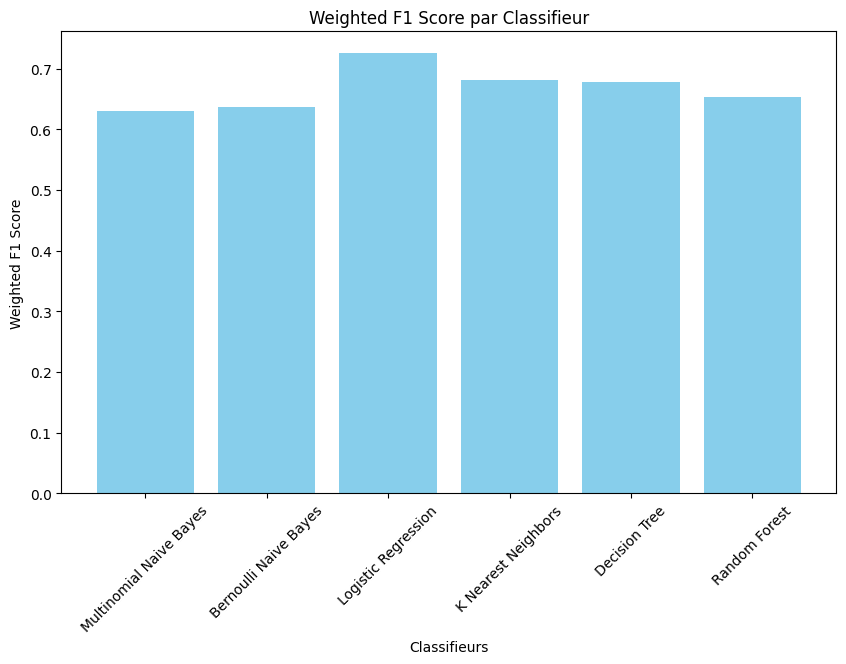

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Séparation des données (caractéristiques et cible)
X = concat_df
y = train_df['cal_réponse_signalement']  # La variable cible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Création et entraînement des modèles
models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Bernoulli Naive Bayes': BernoulliNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'K Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

# Évaluation des modèles
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calcul des métriques
    accuracy = accuracy_score(y_test, y_pred)
    weighted_f1 = f1_score(y_test, y_pred, average='weighted', pos_label="Pris en compte")
    report = classification_report(y_test, y_pred, zero_division=0)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)

    # Affichage des résultats
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Weighted F1 Score: {weighted_f1:.2f}")
    print(f"Classification Report:\n{report}")
    print(f"Cross-Validation Mean Accuracy: {cv_scores.mean():.2f}")
    print('-' * 50)


# Visualisation de l'évolution du weighted F1 score par classifieur
plt.figure(figsize=(10, 6))
plt.bar(models.keys(), f1_scores, color='skyblue')
plt.title('Weighted F1 Score par Classifieur')
plt.xlabel('Classifieurs')
plt.ylabel('Weighted F1 Score')
plt.xticks(rotation=45)
plt.show()

On constate qu'avec l'ajout de certaines variables, il y a une légère amélioration des classifieurs, notamment le modèle de régression logistique, qui a atteint un 'weighted F1-score' de 74 %.

##  Modèle de regression logistique en utilisant les meilleurs hyperparamètres

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

# Utiliser final_df sans réduction de dimension comme ensemble de données
X = concat_df # Les données vectorisées sans réduction de dimension
y = train_df['cal_réponse_signalement']  # Variable cible

# Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Définition de l'espace des hyperparamètres pour la régression logistique
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Essai de différentes valeurs pour le paramètre de régularisation
    'solver': ['liblinear', 'lbfgs'],  # Différents solveurs possibles pour optimiser
    'penalty': ['l2'],  # 'l1' est disponible uniquement pour le solver 'liblinear'
    'max_iter': [100, 200, 500]  # Tester différents nombres d'itérations
}

# Initialisation du modèle de régression logistique
log_reg = LogisticRegression()

# Utilisation de GridSearchCV pour la recherche d'hyperparamètres
grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)

# Exécution de GridSearchCV
grid_search.fit(X_train, y_train)

# Affichage des meilleurs hyperparamètres
print("Meilleurs hyperparamètres :", grid_search.best_params_)

# Entraînement du modèle avec les meilleurs hyperparamètres
best_log_reg = grid_search.best_estimator_
best_log_reg.fit(X_train, y_train)
y_pred = best_log_reg.predict(X_test)

# Calcul du weighted F1 score et affichage du rapport de classification
weighted_f1 = f1_score(y_test, y_pred, average='weighted',pos_label="Pris en compte")
report = classification_report(y_test, y_pred, zero_division=0)

print("\nOptimisation de la régression logistique :")
print(f"Weighted F1 Score après optimisation : {weighted_f1:.2f}")
print("Classification Report :\n", report)


Meilleurs hyperparamètres : {'C': 1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}

Optimisation de la régression logistique :
Weighted F1 Score après optimisation : 0.74
Classification Report :
                      precision    recall  f1-score   support

     Pris en compte       0.80      0.92      0.85       741
Rejete (hors specs)       0.58      0.33      0.42       259

           accuracy                           0.77      1000
          macro avg       0.69      0.62      0.64      1000
       weighted avg       0.74      0.77      0.74      1000



C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'Pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


#### Après avoir testé les meilleurs hyperparamètres du modèle, on constate qu'il n'y a pas d'évolution du 'weighted F1-score'. Donc, nous allons revoir notre étape de pré-traitement et également la sélection des variables à intégrer dans le data frame.

## Racinisation et vectorisation des données avec une réduction des données moins importante et avec un comptage pondéré.

À ce stade, nous allons choisir une réduction des données moins importante, soit 10 000, pour optimiser la puissance de calcul et l'utilisation de la mémoire. En outre, cette étape nous permettra d'avoir plus de données, car initialement nous avions drastiquement réduit les données, ce qui peut potentiellement affecter l'efficacité des classifieurs en raison d'un nombre insuffisant de données. Notre prochaine approche sera donc d'avoir plus de données et de trouver les meilleurs paramètres pour la réduction des dimensions afin de conserver uniquement les informations principales.

In [ ]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
import nltk

# Télécharger les stopwords français si nécessaire
nltk.download('stopwords')

# Définir les colonnes textuelles et catégorielles
text_columns = ['boamp_theme_boamp', 'boamp_intitule', 'texte_annonce']
categorical_columns = ['cal_mot_rang_1', 'cal_mot_rang_2', 'boamp_libelle_annonce']

# Initialiser le raciniseur pour le français
stemmer = SnowballStemmer('french')

# Fonction de nettoyage des textes
def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'[^\w\s]', ' ', text)  # Retirer la ponctuation
    words = text.lower().split()
    words = [word for word in words if word not in stopwords.words('french')]  # Supprimer les stopwords
    return ' '.join(words)

# Fonction de racinisation des textes
def stem_text(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

# Étape 1 : Appliquer le nettoyage et la racinisation aux colonnes textuelles
for col in text_columns:
    train_df[col] = train_df[col].apply(lambda x: stem_text(clean_text(x)))

# Étape 2 : Vectorisation des colonnes textuelles avec TF-IDF (sans réduction des dimensions)
vectorized_dfs = {}
for col in text_columns:
    vectorizer = TfidfVectorizer(max_features=10000,ngram_range=(1, 2))  # Inclut unigrams et bigrams
    vectorized_df = pd.DataFrame(
        vectorizer.fit_transform(train_df[col]).toarray(),
        columns=[f"{col}_{feat}" for feat in vectorizer.get_feature_names_out()]
    )
    vectorized_dfs[col] = vectorized_df

# Étape 3 : Encodage des colonnes catégorielles avec OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
categorical_encoded = pd.DataFrame(
    encoder.fit_transform(train_df[categorical_columns]),
    columns=encoder.get_feature_names_out(categorical_columns)
)

# Étape 4 : Concaténer toutes les colonnes vectorisées et encodées
concat1_df = pd.concat([*vectorized_dfs.values(), categorical_encoded], axis=1)

# Affichage d'un échantillon des données finales
print(concat1_df.head())


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\diall\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   boamp_theme_boamp_abon  boamp_theme_boamp_abon equip  \
0                     0.0                           0.0   
1                     0.0                           0.0   
2                     0.0                           0.0   
3                     0.0                           0.0   
4                     0.0                           0.0   

   boamp_theme_boamp_abris  boamp_theme_boamp_abris abon  \
0                      0.0                           0.0   
1                      0.0                           0.0   
2                      0.0                           0.0   
3                      0.0                           0.0   
4                      0.0                           0.0   

   boamp_theme_boamp_abris bardag  boamp_theme_boamp_abris contrôl  \
0                             0.0                              0.0   
1                             0.0                              0.0   
2                             0.0                              0.0   
3   

## Trouver les meilleurs paramètres pour la reduction des dimensions

Dans cette étape, nous avons intégré une recherche systématique des meilleurs hyperparamètres pour la réduction des dimensions avec TruncatedSVD, tout en testant plusieurs modèles d'apprentissage supervisé (Logistic Regression, Random Forest, KNN et XGBoost). L'objectif était de déterminer la valeur optimale de n_components, c'est-à-dire le nombre de dimensions réduites, qui maximise les performances des modèles en termes de F1 score pondéré.

Testing n_components=50


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py:158: UserWarning: [11:14:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Testing n_components=100


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py:158: UserWarning: [11:14:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Testing n_components=150


...

C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py:158: UserWarning: [11:16:16] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Testing n_components=350


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py:158: UserWarning: [11:16:52] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Testing n_components=400


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py:158: UserWarning: [11:17:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


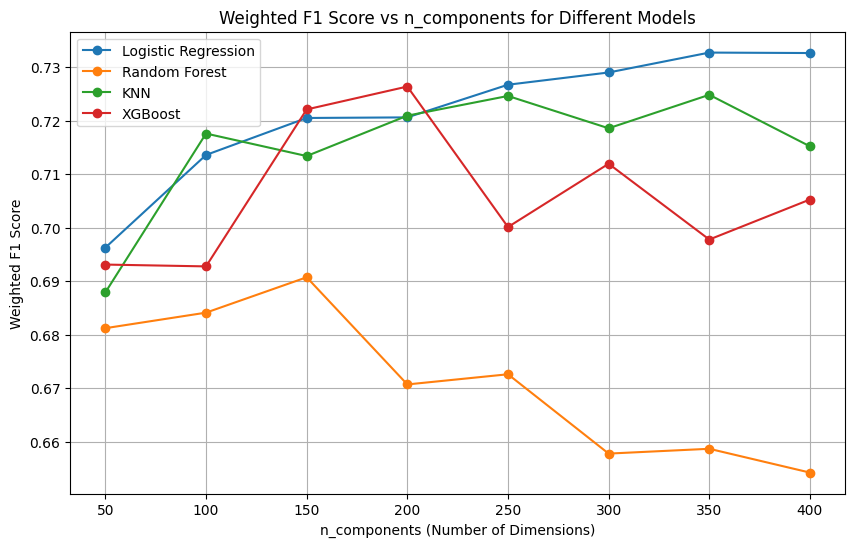

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Données vectorisées (concat1_df) et cible (train_df['cal_réponse_signalement'])
X = concat1_df
y = train_df['cal_réponse_signalement']

# Étape d'encodage des classes cibles
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Séparation des données
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Plage de valeurs pour n_components à tester
n_components_range = list(range(50, 401, 50))

# Initialiser les modèles
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

# Dictionnaire pour stocker les F1 scores
model_scores = {model: [] for model in models.keys()}

# Tester différentes valeurs de n_components
for n_components in n_components_range:
    print(f"Testing n_components={n_components}")
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    X_train_reduced = svd.fit_transform(X_train)
    X_test_reduced = svd.transform(X_test)

    # Évaluer chaque modèle avec les données réduites
    for model_name, model in models.items():
        model.fit(X_train_reduced, y_train)
        y_pred = model.predict(X_test_reduced)
        f1 = f1_score(y_test, y_pred, average='weighted')
        model_scores[model_name].append(f1)

# Visualisation des résultats
plt.figure(figsize=(10, 6))
for model_name, scores in model_scores.items():
    plt.plot(n_components_range, scores, marker='o', label=model_name)

plt.title("Weighted F1 Score vs n_components for Different Models")
plt.xlabel("n_components (Number of Dimensions)")
plt.ylabel("Weighted F1 Score")
plt.legend()
plt.grid()
plt.show()


Le graphique montre les scores F1 pondérés de quatre modèles en fonction du nombre de dimensions (n_components) :

- Régression Logistique (bleu) : Performances stables et croissantes, atteignant le meilleur score (~0,73) avec un nombre élevé de dimensions. Ce modèle est le plus robuste face à l'augmentation des dimensions.

- Random Forest (orange) : Performance en baisse continue à mesure que les dimensions augmentent, montrant une sensibilité élevée aux grandes dimensions.

- K-Nearest Neighbors (KNN, vert) : Amélioration initiale jusqu'à environ 200 dimensions, puis légère baisse, indiquant une limite face à des dimensions élevées.

- XGBoost (rouge) : Bonne performance jusqu’à 150 dimensions, puis déclin marqué avant une légère reprise, montrant une sensibilité aux dimensions élevées.

## Évaluation du modèle de régression logistique avec les meilleurs hyperparamètres et une réduction des dimensions à 400.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from sklearn.decomposition import TruncatedSVD

# Utiliser final_df sans réduction de dimension comme ensemble de données
X = concat1_df  # Les données vectorisées sans réduction de dimension
y = train_df['cal_réponse_signalement']  # Variable cible

# Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Appliquer la réduction des dimensions à 400
n_components = 400  # Nombre de dimensions après réduction
svd = TruncatedSVD(n_components=n_components, random_state=42)


# Réduction de dimension sur les données d'entraînement et de test
X_train_reduced = svd.fit_transform(X_train)
X_test_reduced = svd.transform(X_test)

# Définition de l'espace des hyperparamètres pour la régression logistique
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Essai de différentes valeurs pour le paramètre de régularisation
    'solver': ['liblinear', 'lbfgs'],  # Différents solveurs possibles pour optimiser
    'penalty': ['l2'],  # 'l1' est disponible uniquement pour le solver 'liblinear'
    'max_iter': [100, 200, 500]  # Tester différents nombres d'itérations
}

# Initialisation du modèle de régression logistique
log_reg = LogisticRegression()

# Utilisation de GridSearchCV pour la recherche d'hyperparamètres
grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)

# Exécution de GridSearchCV sur les données réduites
grid_search.fit(X_train_reduced, y_train)

# Affichage des meilleurs hyperparamètres
print("Meilleurs hyperparamètres :", grid_search.best_params_)

# Entraînement du modèle avec les meilleurs hyperparamètres
best_log_reg = grid_search.best_estimator_
best_log_reg.fit(X_train_reduced, y_train)
y_pred = best_log_reg.predict(X_test_reduced)

# Calcul du weighted F1 score et affichage du rapport de classification
weighted_f1 = f1_score(y_test, y_pred, average='weighted', pos_label="Pris en compte")
report = classification_report(y_test, y_pred, zero_division=0)

print("\nOptimisation de la régression logistique :")
print(f"Weighted F1 Score après optimisation : {weighted_f1:.2f}")
print("Classification Report :\n", report)


Meilleurs hyperparamètres : {'C': 100, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}

Optimisation de la régression logistique :
Weighted F1 Score après optimisation : 0.75
Classification Report :
                      precision    recall  f1-score   support

     Pris en compte       0.81      0.91      0.85       741
Rejete (hors specs)       0.59      0.39      0.47       259

           accuracy                           0.77      1000
          macro avg       0.70      0.65      0.66      1000
       weighted avg       0.75      0.77      0.75      1000



C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'Pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


On constate une évolution considérable du 'weighted F1-score' après l'optimisation de l'étape de pré-traitement et l'identification des meilleurs hyperparamètres du modèle de régression logistique, qui pour l'instant est le classifieur le plus adapté en termes de bonnes prédictions. Pour la suite, nous allons également évaluer le classifieur, mais cette fois sur les données de test.


# Pré-Traitement fichier de test

Entraînement et Sauvegarde :

- Nous avons créé et entraîné des objets comme TfidfVectorizer et OneHotEncoder sur les données d'entraînement.

- Ces objets ont été sauvegardés dans des fichiers .pkl via joblib.dump.

Pré-traitement des Données de Test :

- Nous avons chargé les objets sauvegardés à l'aide de joblib.load().

- Nous avons appliqué ces objets aux données de test pour obtenir les mêmes transformations que celles réalisées sur les données d'entraînement.

- Nous avons ajouté des colonnes manquantes avec des zéros et supprimé les colonnes supplémentaires pour assurer que les colonnes du jeu de données de test correspondent à celles du jeu de données d'entraînement.

### Entraînement des objets sur les données d'entraînement et sauvegarde

In [ ]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
import joblib
import nltk

# Télécharger les stopwords français si nécessaire
nltk.download('stopwords')

# Définir les colonnes textuelles et catégorielles
text_columns = ['boamp_theme_boamp', 'boamp_intitule', 'texte_annonce']
categorical_columns = ['cal_mot_rang_1', 'cal_mot_rang_2', 'boamp_libelle_annonce']

# Initialiser le raciniseur pour le français
stemmer = SnowballStemmer('french')

# Fonction de nettoyage des textes
def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'[^\w\s]', ' ', text)  # Retirer la ponctuation
    words = text.lower().split()
    words = [word for word in words if word not in stopwords.words('french')]  # Supprimer les stopwords
    return ' '.join(words)

# Fonction de racinisation des textes
def stem_text(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

# Charger et prétraiter les données d'entraînement
train_df = pd.read_excel("data_train.xlsx")
train_df = train_df.drop(['boamp_id_annonce', 'boamp_parent_annonce', 'cal_fichier_pdf',
                          'cal_num_signalement', 'boamp_siret_acheteur', 'cal_adresse_annonce'], axis=1)

# Appliquer le nettoyage et la racinisation aux colonnes textuelles
for col in text_columns:
    train_df[col] = train_df[col].apply(lambda x: stem_text(clean_text(x)))

# Vectorisation des colonnes textuelles avec TfidfVectorizer
vectorizer1 = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
vectorizer2 = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
vectorizer3 = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# Entraîner les vectorizers sur les données d'entraînement
vectorizer1.fit(train_df['boamp_theme_boamp'])
vectorizer2.fit(train_df['boamp_intitule'])
vectorizer3.fit(train_df['texte_annonce'])

# Sauvegarder les vectorizers
joblib.dump(vectorizer1, 'trained_vectorizer1.pkl')
joblib.dump(vectorizer2, 'trained_vectorizer2.pkl')
joblib.dump(vectorizer3, 'trained_vectorizer3.pkl')

# Entraîner l'encoder pour les colonnes catégorielles
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(train_df[['cal_mot_rang_1', 'cal_mot_rang_2', 'boamp_libelle_annonce']])

# Sauvegarder l'encoder
joblib.dump(encoder, 'trained_one_hot_encoder.pkl')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\diall\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['trained_one_hot_encoder.pkl']

### Appliquer le pré-traitement sur les données de test

In [ ]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import joblib
import nltk

# Télécharger les stopwords français si nécessaire
nltk.download('stopwords')

# Définir les colonnes textuelles et catégorielles
text_columns = ['boamp_theme_boamp', 'boamp_intitule', 'texte_annonce']
categorical_columns = ['cal_mot_rang_1', 'cal_mot_rang_2', 'boamp_libelle_annonce']

# Initialiser le raciniseur pour le français
stemmer = SnowballStemmer('french')

# Fonction de nettoyage des textes
def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'[^\w\s]', ' ', text)  # Retirer la ponctuation
    words = text.lower().split()
    words = [word for word in words if word not in stopwords.words('french')]  # Supprimer les stopwords
    return ' '.join(words)

# Fonction de racinisation des textes
def stem_text(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

# Charger les objets préalablement entraînés (vectorizers et encoder)
trained_vectorizer1 = joblib.load('trained_vectorizer1.pkl')
trained_vectorizer2 = joblib.load('trained_vectorizer2.pkl')
trained_vectorizer3 = joblib.load('trained_vectorizer3.pkl')
trained_one_hot_encoder = joblib.load('trained_one_hot_encoder.pkl')

# Charger et prétraiter les données de test
test_df = pd.read_excel("data_test.xlsx")
test_df = test_df.drop(['boamp_id_annonce', 'boamp_parent_annonce', 'cal_fichier_pdf',
                        'cal_num_signalement', 'boamp_siret_acheteur', 'cal_adresse_annonce'], axis=1)

# Appliquer le nettoyage et la racinisation aux colonnes textuelles
for col in text_columns:
    test_df[col] = test_df[col].apply(lambda x: stem_text(clean_text(x)))

# Vectorisation des données de test avec les vectorizers entraînés
vectorized_test_dfs = {}
for col in text_columns:
    if col == 'boamp_theme_boamp':
        vectorized_test_df = pd.DataFrame(
            trained_vectorizer1.transform(test_df[col]).toarray(),
            columns=[f"{col}_{feat}" for feat in trained_vectorizer1.get_feature_names_out()]
        )
    elif col == 'boamp_intitule':
        vectorized_test_df = pd.DataFrame(
            trained_vectorizer2.transform(test_df[col]).toarray(),
            columns=[f"{col}_{feat}" for feat in trained_vectorizer2.get_feature_names_out()]
        )
    elif col == 'texte_annonce':
        vectorized_test_df = pd.DataFrame(
            trained_vectorizer3.transform(test_df[col]).toarray(),
            columns=[f"{col}_{feat}" for feat in trained_vectorizer3.get_feature_names_out()]
        )
    vectorized_test_dfs[col] = vectorized_test_df

# Encodage des colonnes catégorielles avec l'encoder entraîné
categorical_encoded_test = pd.DataFrame(
    trained_one_hot_encoder.transform(test_df[categorical_columns]),
    columns=trained_one_hot_encoder.get_feature_names_out(categorical_columns)
)

# Concaténer toutes les colonnes vectorisées et encodées
concat_test_df = pd.concat([*vectorized_test_dfs.values(), categorical_encoded_test], axis=1)

# Assurez-vous que les colonnes correspondent à celles des données d'entraînement
missing_cols = set(concat1_df.columns) - set(concat_test_df.columns)
for col in missing_cols:
    concat_test_df[col] = 0  # Ajouter les colonnes manquantes avec des zéros

extra_cols = set(concat_test_df.columns) - set(concat1_df.columns)
concat_test_df = concat_test_df.drop(columns=extra_cols)  # Supprimer les colonnes supplémentaires
concat_test_df = concat_test_df[concat1_df.columns]  # Réordonner les colonnes

# Afficher un échantillon des données de test traitées
print(concat_test_df.head())



## Evaluation du modèle de regression logistique avec les meilleurs hyperparamètres sur les données de test

In [ ]:
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

# Données d'entraînement pré-traitées
X_train = concat1_df
y_train = train_df['cal_réponse_signalement']

# Données de test pré-traitées
X_test = concat_test_df

# Réduction des dimensions avec TruncatedSVD (n_components=400)
n_components = 400
svd = TruncatedSVD(n_components=n_components, random_state=42)

# Appliquer SVD sur les données d'entraînement et de test
X_train_reduced = svd.fit_transform(X_train)
X_test_reduced = svd.transform(X_test)

# Initialisation du modèle de régression logistique avec les meilleurs hyperparamètres
best_log_reg = LogisticRegression(
    C=100,
    max_iter=100,
    penalty='l2',
    solver='liblinear',
    random_state=42
)

# Entraîner le modèle sur les données réduites d'entraînement
best_log_reg.fit(X_train_reduced, y_train)

# Prédictions sur les données de test
test_predictions = best_log_reg.predict(X_test_reduced)

# weighted_f1 = f1_score(y_test, test_predictions, average='weighted', pos_label="Pris en compte")
# print(f"Weighted F1 Score : {weighted_f1:.2f}")

# Créer un DataFrame avec les résultats
output_df = pd.DataFrame({
    'OGC_FID': test_df['OGC_FID'],  # Identifier unique des données de test
    'cal_réponse_signalement': test_predictions
})

# Exporter les résultats dans un fichier CSV
output_df.to_csv('test_predictions.csv', index=False)

# Afficher un message de confirmation
print("Les prédictions ont été sauvegardées dans 'test_predictions.csv'.")


Les prédictions ont été sauvegardées dans 'test_predictions.csv'.


#  Conclusion partielle 1

Avec toutes les étapes effectuées, nous avons constaté que la partie qui a le plus impacté l'amélioration des classifieurs est la partie de pré-traitement des données. Pour l'instant, nous avons obtenu le meilleur classifieur, qui est le modèle de régression logistique avec un 'weighted F1-score' de 0,75, tout en ayant sélectionné les meilleurs hyperparamètres du modèle, puis avec une racinisation, un comptage pondéré et une réduction des dimensions. Nous avons également constaté que l'ajout de certaines variables a un impact plutôt positif. Nous allons donc davantage nous concentrer sur l'amélioration de l'étape de pré-traitement tout en identifiant d'autres variables qui pourraient potentiellement améliorer les bonnes prédictions du modèle.

## Impact des variables sur les réponses de la variable cible

Avant de passer à l'étape d'optimisation du pré-traitement des données, nous allons observer les différentes variables qui pourraient potentiellement avoir un impact sur les réponses de la variable cible.

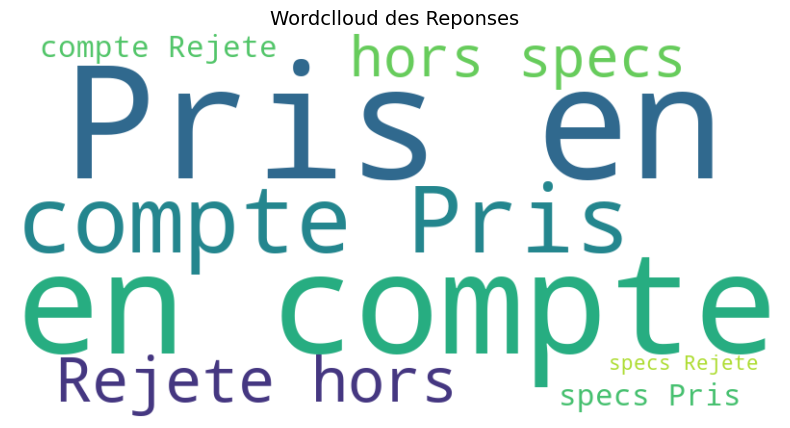

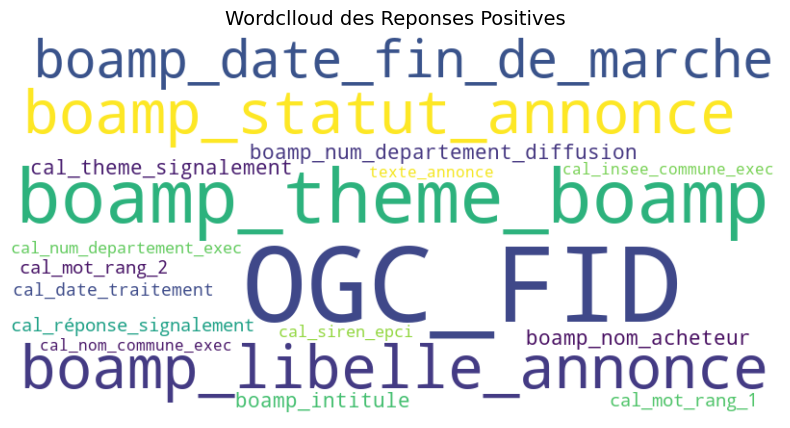

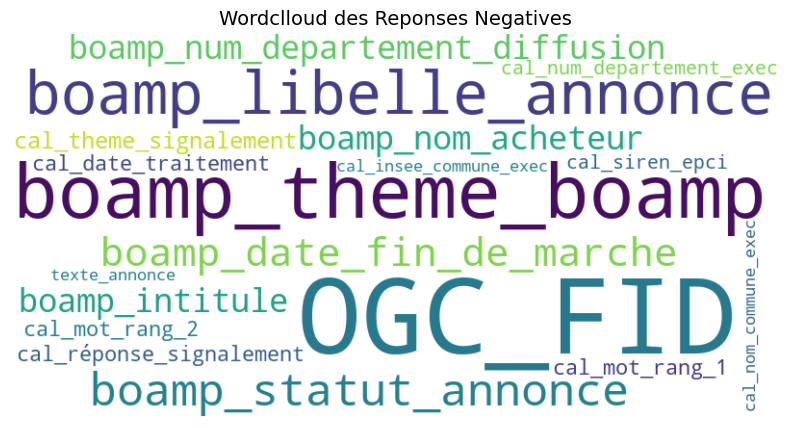

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as  plt

def generer_wordcloud(texte, titre):
    all_texte = ' '.join(texte)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_texte)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(titre, fontsize=14)
    plt.axis('off')
    plt.show()


generer_wordcloud(train_df['cal_réponse_signalement'], 'Wordclloud des Reponses')
generer_wordcloud(train_df[train_df['cal_réponse_signalement']=='Pris en compte'], 'Wordclloud des Reponses Positives')
generer_wordcloud(train_df[train_df['cal_réponse_signalement']=='Rejete (hors specs)'], 'Wordclloud des Reponses Negatives')

Après avoir utilisé cette bibliothèque qui nous permet d'observer l'impact des autres variables sur notre variable cible, nous constatons que le choix de nos variables est pertinent et qu'en plus, cela nous permet d'en rajouter davantage et d'optimiser notre pré-traitement.

## Optimisation du pré-traitement avec l'ajout de quelques variables

Dans un premier temps nous avons choisi de rajouter trois variables dans le but de voir si l'ajout de ces variables sera vraiment signifiatif .
les variables ajoutées : 'boamp_statut_annonce', 'cal_theme_signalement','boamp_num_departement_diffusion'

In [ ]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
import nltk

# Télécharger les stopwords français si nécessaire
nltk.download('stopwords')

# Définir les colonnes textuelles et catégorielles
text_columns = ['boamp_theme_boamp', 'boamp_intitule', 'texte_annonce']
categorical_columns = ['cal_mot_rang_1', 'cal_mot_rang_2', 'boamp_libelle_annonce','boamp_statut_annonce', 'cal_theme_signalement','boamp_num_departement_diffusion']

# Initialiser le raciniseur pour le français
stemmer = SnowballStemmer('french')

# Fonction de nettoyage des textes
def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'[^\w\s]', ' ', text)  # Retirer la ponctuation
    words = text.lower().split()
    words = [word for word in words if word not in stopwords.words('french')]  # Supprimer les stopwords
    return ' '.join(words)

# Fonction de racinisation des textes
def stem_text(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

# Étape 1 : Appliquer le nettoyage et la racinisation aux colonnes textuelles
for col in text_columns:
    train_df[col] = train_df[col].apply(lambda x: stem_text(clean_text(x)))

# Étape 2 : Vectorisation des colonnes textuelles avec TF-IDF (sans réduction des dimensions)
vectorized_dfs = {}
for col in text_columns:
    vectorizer = TfidfVectorizer(max_features=10000,ngram_range=(1, 2))  # Inclut unigrams et bigrams
    vectorized_df = pd.DataFrame(
        vectorizer.fit_transform(train_df[col]).toarray(),
        columns=[f"{col}_{feat}" for feat in vectorizer.get_feature_names_out()]
    )
    vectorized_dfs[col] = vectorized_df

# Étape 3 : Encodage des colonnes catégorielles avec OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
categorical_encoded = pd.DataFrame(
    encoder.fit_transform(train_df[categorical_columns]),
    columns=encoder.get_feature_names_out(categorical_columns)
)

# Étape 4 : Concaténer toutes les colonnes vectorisées et encodées
concat3_df = pd.concat([*vectorized_dfs.values(), categorical_encoded], axis=1)

# Affichage d'un échantillon des données finales
print(concat3_df.head())


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\diall\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   boamp_theme_boamp_abon  boamp_theme_boamp_abon equip  \
0                     0.0                           0.0   
1                     0.0                           0.0   
2                     0.0                           0.0   
3                     0.0                           0.0   
4                     0.0                           0.0   

   boamp_theme_boamp_abris  boamp_theme_boamp_abris abon  \
0                      0.0                           0.0   
1                      0.0                           0.0   
2                      0.0                           0.0   
3                      0.0                           0.0   
4                      0.0                           0.0   

   boamp_theme_boamp_abris bardag  boamp_theme_boamp_abris contrôl  \
0                             0.0                              0.0   
1                             0.0                              0.0   
2                             0.0                              0.0   
3   

## Classification et évaluation des modèles

C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


Model: Bernoulli Naive Bayes
Accuracy: 0.75
Weighted F1 Score: 0.74
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.81      0.86      0.83       741
Rejete (hors specs)       0.52      0.43      0.47       259

           accuracy                           0.75      1000
          macro avg       0.66      0.65      0.65      1000
       weighted avg       0.74      0.75      0.74      1000

Cross-Validation Mean Accuracy: 0.69
--------------------------------------------------


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


Model: Logistic Regression
Accuracy: 0.81
Weighted F1 Score: 0.79
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.83      0.93      0.88       741
Rejete (hors specs)       0.69      0.46      0.55       259

           accuracy                           0.81      1000
          macro avg       0.76      0.69      0.71      1000
       weighted avg       0.79      0.81      0.79      1000

Cross-Validation Mean Accuracy: 0.76
--------------------------------------------------


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


Model: K Nearest Neighbors
Accuracy: 0.74
Weighted F1 Score: 0.73
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.80      0.86      0.83       741
Rejete (hors specs)       0.49      0.39      0.44       259

           accuracy                           0.74      1000
          macro avg       0.65      0.62      0.63      1000
       weighted avg       0.72      0.74      0.73      1000

Cross-Validation Mean Accuracy: 0.72
--------------------------------------------------


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


Model: Decision Tree
Accuracy: 0.68
Weighted F1 Score: 0.68
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.78      0.79      0.79       741
Rejete (hors specs)       0.38      0.36      0.37       259

           accuracy                           0.68      1000
          macro avg       0.58      0.58      0.58      1000
       weighted avg       0.68      0.68      0.68      1000

Cross-Validation Mean Accuracy: 0.67
--------------------------------------------------


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


Model: Random Forest
Accuracy: 0.75
Weighted F1 Score: 0.68
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.76      0.97      0.85       741
Rejete (hors specs)       0.62      0.12      0.20       259

           accuracy                           0.75      1000
          macro avg       0.69      0.55      0.53      1000
       weighted avg       0.72      0.75      0.68      1000

Cross-Validation Mean Accuracy: 0.73
--------------------------------------------------


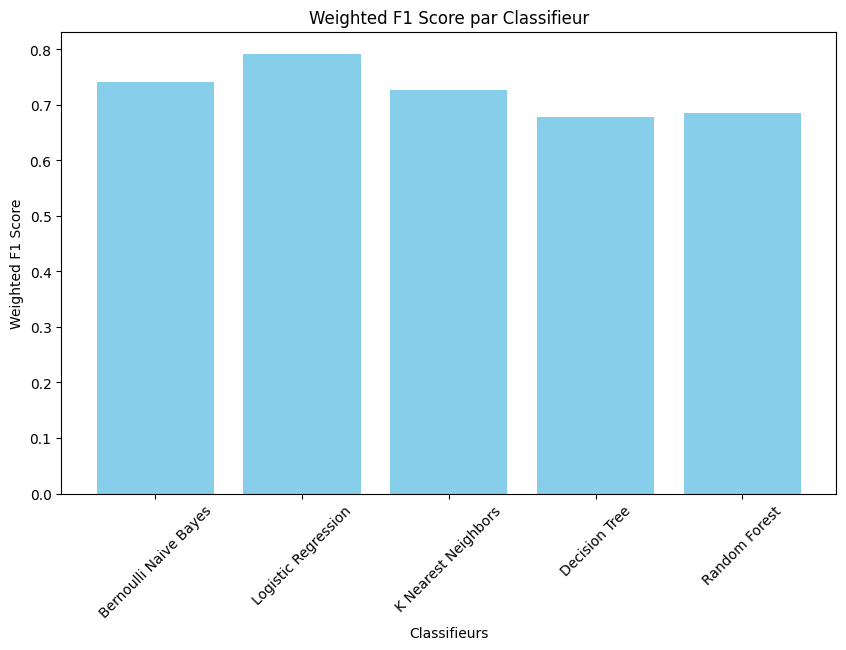

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
import matplotlib.pyplot as plt


X = concat3_df  # Matrice des caractéristiques pré-traitées
y = train_df['cal_réponse_signalement']  # La variable cible

# Division des données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Définition des modèles
models = {
    # 'Multinomial Naive Bayes': MultinomialNB(),
    'Bernoulli Naive Bayes': BernoulliNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'K Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

# Dictionnaire pour stocker les scores F1 pondérés
f1_scores = {}

# Évaluation des modèles
for name, model in models.items():
    # Entraînement du modèle
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calcul des métriques
    accuracy = accuracy_score(y_test, y_pred)
    weighted_f1 = f1_score(y_test, y_pred, average='weighted',pos_label='pris en compte')
    report = classification_report(y_test, y_pred, zero_division=0)
    cv_scores = cross_val_score(model, X_train, y_train, cv=10)

    # Stocker le F1 Score pondéré
    f1_scores[name] = weighted_f1

    # Affichage des résultats
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Weighted F1 Score: {weighted_f1:.2f}")
    print(f"Classification Report:\n{report}")
    print(f"Cross-Validation Mean Accuracy: {cv_scores.mean():.2f}")
    print('-' * 50)

# Visualisation des résultats
plt.figure(figsize=(10, 6))
plt.bar(f1_scores.keys(), f1_scores.values(), color='skyblue')
plt.title('Weighted F1 Score par Classifieur')
plt.xlabel('Classifieurs')
plt.ylabel('Weighted F1 Score')
plt.xticks(rotation=45)
plt.show()


Après avoir optimisé notre pré-traitement avec l'ajout de quelques variables, nous avons observé un impact significatif sur nos classifieurs, en particulier sur le modèle de régression logistique qui a atteint un F1-score de 0,79. De plus, nous avons changé un paramètre au niveau de la validation croisée, qui est maintenant à 10 plis, contrairement aux anciens tests où elle était à 5.

## Evaluation du modèle de regression logistique avec les meilleurs hyperparamètres

Meilleurs hyperparamètres : {'C': 1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'Pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(



Optimisation de la régression logistique :
Weighted F1 Score après optimisation : 0.79
Classification Report :
                      precision    recall  f1-score   support

     Pris en compte       0.83      0.93      0.88       741
Rejete (hors specs)       0.69      0.47      0.56       259

           accuracy                           0.81      1000
          macro avg       0.76      0.70      0.72      1000
       weighted avg       0.79      0.81      0.79      1000



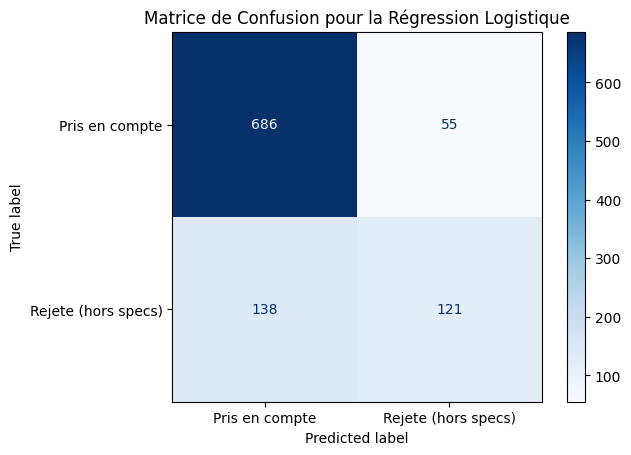

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Utiliser final_df sans réduction de dimension comme ensemble de données
X = concat3_df  # Les données vectorisées sans réduction de dimension
y = train_df['cal_réponse_signalement']  # Variable cible

# Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Définition de l'espace des hyperparamètres pour la régression logistique
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Essai de différentes valeurs pour le paramètre de régularisation
    'solver': ['liblinear', 'lbfgs'],  # Différents solveurs possibles pour optimiser
    'penalty': ['l2'],  # 'l1' est disponible uniquement pour le solver 'liblinear'
    'max_iter': [100, 200, 500]  # Tester différents nombres d'itérations
}

# Initialisation du modèle de régression logistique
log_reg = LogisticRegression()

# Utilisation de GridSearchCV pour la recherche d'hyperparamètres
grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=10, scoring='f1_weighted', n_jobs=-1)

# Exécution de GridSearchCV
grid_search.fit(X_train, y_train)

# Affichage des meilleurs hyperparamètres
print("Meilleurs hyperparamètres :", grid_search.best_params_)

# Entraînement du modèle avec les meilleurs hyperparamètres
best_log_reg = grid_search.best_estimator_
best_log_reg.fit(X_train, y_train)
y_pred = best_log_reg.predict(X_test)

# Calcul du weighted F1 score et affichage du rapport de classification
weighted_f1 = f1_score(y_test, y_pred, average='weighted', pos_label="Pris en compte")
report = classification_report(y_test, y_pred, zero_division=0)

print("\nOptimisation de la régression logistique :")
print(f"Weighted F1 Score après optimisation : {weighted_f1:.2f}")
print("Classification Report :\n", report)

# Calcul et affichage de la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=best_log_reg.classes_).plot(cmap='Blues')
plt.title("Matrice de Confusion pour la Régression Logistique")
plt.show()


## Appliquer le pré-traitement sur le fichier de test et tester sur Kaggle

In [ ]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
import joblib
import nltk

# Télécharger les stopwords français si nécessaire
nltk.download('stopwords')

# Définir les colonnes textuelles et catégorielles
text_columns = ['boamp_theme_boamp', 'boamp_intitule', 'texte_annonce']
categorical_columns = ['cal_mot_rang_1', 'cal_mot_rang_2', 'boamp_libelle_annonce','boamp_statut_annonce', 'cal_theme_signalement','boamp_num_departement_diffusion']

# Initialiser le raciniseur pour le français
stemmer = SnowballStemmer('french')

# Fonction de nettoyage des textes
def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'[^\w\s]', ' ', text)  # Retirer la ponctuation
    words = text.lower().split()
    words = [word for word in words if word not in stopwords.words('french')]  # Supprimer les stopwords
    return ' '.join(words)

# Fonction de racinisation des textes
def stem_text(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

# Charger et prétraiter les données d'entraînement
train_df = pd.read_excel("data_train.xlsx")
train_df = train_df.drop(['boamp_id_annonce', 'boamp_parent_annonce', 'cal_fichier_pdf',
                          'cal_num_signalement', 'boamp_siret_acheteur', 'cal_adresse_annonce'], axis=1)

# Appliquer le nettoyage et la racinisation aux colonnes textuelles
for col in text_columns:
    train_df[col] = train_df[col].apply(lambda x: stem_text(clean_text(x)))

# Vectorisation des colonnes textuelles avec TfidfVectorizer
vectorizer1 = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
vectorizer2 = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
vectorizer3 = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# Entraîner les vectorizers sur les données d'entraînement
vectorizer1.fit(train_df['boamp_theme_boamp'])
vectorizer2.fit(train_df['boamp_intitule'])
vectorizer3.fit(train_df['texte_annonce'])

# Sauvegarder les vectorizers
joblib.dump(vectorizer1, 'trained_vectorizer1.pkl')
joblib.dump(vectorizer2, 'trained_vectorizer2.pkl')
joblib.dump(vectorizer3, 'trained_vectorizer3.pkl')

# Entraîner l'encoder pour les colonnes catégorielles
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(train_df[['cal_mot_rang_1', 'cal_mot_rang_2', 'boamp_libelle_annonce','boamp_statut_annonce', 'cal_theme_signalement','boamp_num_departement_diffusion']])

# Sauvegarder l'encoder
joblib.dump(encoder, 'trained_one_hot_encoder.pkl')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\diall\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['trained_one_hot_encoder.pkl']

In [ ]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import joblib
import nltk

# Télécharger les stopwords français si nécessaire
nltk.download('stopwords')

# Définir les colonnes textuelles et catégorielles
text_columns = ['boamp_theme_boamp', 'boamp_intitule', 'texte_annonce']
categorical_columns = ['cal_mot_rang_1', 'cal_mot_rang_2', 'boamp_libelle_annonce','boamp_statut_annonce', 'cal_theme_signalement','boamp_num_departement_diffusion']

# Initialiser le raciniseur pour le français
stemmer = SnowballStemmer('french')

# Fonction de nettoyage des textes
def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'[^\w\s]', ' ', text)  # Retirer la ponctuation
    words = text.lower().split()
    words = [word for word in words if word not in stopwords.words('french')]  # Supprimer les stopwords
    return ' '.join(words)

# Fonction de racinisation des textes
def stem_text(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

# Charger les objets préalablement entraînés (vectorizers et encoder)
trained_vectorizer1 = joblib.load('trained_vectorizer1.pkl')
trained_vectorizer2 = joblib.load('trained_vectorizer2.pkl')
trained_vectorizer3 = joblib.load('trained_vectorizer3.pkl')
trained_one_hot_encoder = joblib.load('trained_one_hot_encoder.pkl')

# Charger et prétraiter les données de test
test_df = pd.read_excel("data_test.xlsx")
test_df = test_df.drop(['boamp_id_annonce', 'boamp_parent_annonce', 'cal_fichier_pdf',
                        'cal_num_signalement', 'boamp_siret_acheteur', 'cal_adresse_annonce'], axis=1)

# Appliquer le nettoyage et la racinisation aux colonnes textuelles
for col in text_columns:
    test_df[col] = test_df[col].apply(lambda x: stem_text(clean_text(x)))

# Vectorisation des données de test avec les vectorizers entraînés
vectorized_test_dfs = {}
for col in text_columns:
    if col == 'boamp_theme_boamp':
        vectorized_test_df = pd.DataFrame(
            trained_vectorizer1.transform(test_df[col]).toarray(),
            columns=[f"{col}_{feat}" for feat in trained_vectorizer1.get_feature_names_out()]
        )
    elif col == 'boamp_intitule':
        vectorized_test_df = pd.DataFrame(
            trained_vectorizer2.transform(test_df[col]).toarray(),
            columns=[f"{col}_{feat}" for feat in trained_vectorizer2.get_feature_names_out()]
        )
    elif col == 'texte_annonce':
        vectorized_test_df = pd.DataFrame(
            trained_vectorizer3.transform(test_df[col]).toarray(),
            columns=[f"{col}_{feat}" for feat in trained_vectorizer3.get_feature_names_out()]
        )
    vectorized_test_dfs[col] = vectorized_test_df

# Encodage des colonnes catégorielles avec l'encoder entraîné
categorical_encoded_test = pd.DataFrame(
    trained_one_hot_encoder.transform(test_df[categorical_columns]),
    columns=trained_one_hot_encoder.get_feature_names_out(categorical_columns)
)

# Concaténer toutes les colonnes vectorisées et encodées
concat_test_df = pd.concat([*vectorized_test_dfs.values(), categorical_encoded_test], axis=1)

# Assurez-vous que les colonnes correspondent à celles des données d'entraînement
missing_cols = set(concat3_df.columns) - set(concat_test_df.columns)
for col in missing_cols:
    concat_test_df[col] = 0  # Ajouter les colonnes manquantes avec des zéros

extra_cols = set(concat_test_df.columns) - set(concat3_df.columns)
concat_test_df = concat_test_df.drop(columns=extra_cols)  # Supprimer les colonnes supplémentaires
concat_test_df = concat_test_df[concat3_df.columns]  # Réordonner les colonnes

# Afficher un échantillon des données de test traitées
print(concat_test_df.head())



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\diall\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   boamp_theme_boamp_abon  boamp_theme_boamp_abon equip  \
0                     0.0                           0.0   
1                     0.0                           0.0   
2                     0.0                           0.0   
3                     0.0                           0.0   
4                     0.0                           0.0   

   boamp_theme_boamp_abris  boamp_theme_boamp_abris abon  \
0                      0.0                           0.0   
1                      0.0                           0.0   
2                      0.0                           0.0   
3                      0.0                           0.0   
4                      0.0                           0.0   

   boamp_theme_boamp_abris bardag  boamp_theme_boamp_abris contrôl  \
0                             0.0                              0.0   
1                             0.0                              0.0   
2                             0.0                              0.0   
3   

## Appliquer les meilleurs hyperparamètres du modèle de regression logistique sur les données de test

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Données d'entraînement pré-traitées
X_train = concat3_df
y_train = train_df['cal_réponse_signalement']

# Données de test pré-traitées
X_test = concat_test_df

# Initialisation du modèle de régression logistique avec les meilleurs hyperparamètres
best_log_reg = LogisticRegression(
    C=1,             # Hyperparamètre de régularisation trouvé
    max_iter=100,    # Nombre d'itérations optimal
    penalty='l2',    # Pénalité optimale
    solver='liblinear',  # Solveur optimal
    random_state=42
)

# Entraîner le modèle sur les données d'entraînement
best_log_reg.fit(X_train, y_train)

# Prédictions sur les données de test
test_predictions = best_log_reg.predict(X_test)

# Créer un DataFrame avec les résultats
output_df = pd.DataFrame({
    'OGC_FID': test_df['OGC_FID'],  # Identifiant unique des données de test
    'cal_réponse_signalement': test_predictions
})

# Exporter les résultats dans un fichier CSV
output_df.to_csv('test_predictions1.csv', index=False)

# Afficher un message de confirmation
print("Les prédictions ont été sauvegardées dans 'test_predictions1.csv'.")


Les prédictions ont été sauvegardées dans 'test_predictions1.csv'.


# Conclusion partielle 2 :

Le travail réalisé comprend plusieurs étapes clés allant de l'exploration des données textuelles à la modélisation et l'évaluation prédictive. Tout d'abord, des visualisations sous forme de nuages de mots (wordclouds) ont été générées pour analyser la fréquence des termes dans les réponses signalées, avec un focus particulier sur les réponses positives et négatives. Ensuite, un prétraitement des données textuelles a été effectué, incluant le nettoyage (suppression de la ponctuation et des stopwords) et la racinisation des mots pour harmoniser les formes lexicales. Les colonnes textuelles ont été vectorisées à l'aide de TF-IDF, tenant compte de l'importance relative des mots, tandis que les colonnes catégorielles ont été encodées via OneHotEncoder. Ces transformations ont permis de créer une base consolidée pour l'entraînement du modèle. Enfin, une régression logistique a été optimisée grâce à une recherche systématique d’hyperparamètres et évaluée à l'aide de métriques comme le score F1 pondéré, le rapport de classification et une matrice de confusion.

Jusqu'à présent, nous avons constaté que ce qui fonctionne est l'optimisation du pré-traitement en ajoutant des variables pertinentes qui potentiellement auront un impact sur la bonne prévision des deux classes. En outre, le meilleur classifieur que nous avons obtenu est le modèle de régression logistique, ce qui semble logique car ce modèle règle des problèmes de classification entre deux classes. Donc, il est plus apte à généraliser. Néanmoins, nous nous rendons compte que le déséquilibre entre les deux classes 'pris en compte' et 'rejetés hors specs' au niveau de la variable cible a un impact sur la prévision, c'est-à-dire que le modèle arrive à mieux prévoir la classe 'pris en compte' que l'autre classe.

## Optimisation du pré-traitement

Ajout d'une variables : cal_nom_commune_exec

In [ ]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
import nltk

# Télécharger les stopwords français si nécessaire
nltk.download('stopwords')

# Définir les colonnes textuelles et catégorielles
text_columns = ['boamp_theme_boamp', 'boamp_intitule', 'texte_annonce']
categorical_columns = ['cal_mot_rang_1', 'cal_mot_rang_2', 'boamp_libelle_annonce',
                       'boamp_statut_annonce', 'cal_theme_signalement', 'boamp_num_departement_diffusion','cal_nom_commune_exec']

# Initialiser le raciniseur pour le français
stemmer = SnowballStemmer('french')

# Fonction de nettoyage des textes
def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'[^\w\s]', ' ', text)  # Retirer la ponctuation
    words = text.lower().split()
    words = [word for word in words if word not in stopwords.words('french')]  # Supprimer les stopwords
    return ' '.join(words)

# Fonction de racinisation des textes
def stem_text(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

# Étape 1 : Appliquer le nettoyage et la racinisation aux colonnes textuelles
for col in text_columns:
    train_df[col] = train_df[col].apply(lambda x: stem_text(clean_text(x)))

# Étape 2 : Vectorisation des colonnes textuelles avec TF-IDF (sans réduction des dimensions)
vectorized_dfs = {}
for col in text_columns:
    vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))  # Inclut unigrams et bigrams
    vectorized_df = pd.DataFrame(
        vectorizer.fit_transform(train_df[col]).toarray(),
        columns=[f"{col}_{feat}" for feat in vectorizer.get_feature_names_out()]
    )
    vectorized_dfs[col] = vectorized_df

# Étape 3 : Encodage des colonnes catégorielles avec OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
categorical_encoded = pd.DataFrame(
    encoder.fit_transform(train_df[categorical_columns]),
    columns=encoder.get_feature_names_out(categorical_columns)
)


# Étape 4 : Concaténer toutes les colonnes vectorisées et encodées
concat4_df = pd.concat([*vectorized_dfs.values(), categorical_encoded], axis=1)

# Affichage d'un échantillon des données finales
print(concat4_df.head())


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\diall\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   boamp_theme_boamp_abon  boamp_theme_boamp_abon equip  \
0                     0.0                           0.0   
1                     0.0                           0.0   
2                     0.0                           0.0   
3                     0.0                           0.0   
4                     0.0                           0.0   

   boamp_theme_boamp_abris  boamp_theme_boamp_abris abon  \
0                      0.0                           0.0   
1                      0.0                           0.0   
2                      0.0                           0.0   
3                      0.0                           0.0   
4                      0.0                           0.0   

   boamp_theme_boamp_abris bardag  boamp_theme_boamp_abris contrôl  \
0                             0.0                              0.0   
1                             0.0                              0.0   
2                             0.0                              0.0   
3   

## Trouver les meilleurs hyperparamètres pour la réduction de dimension

Testing n_components=1200
Testing n_components=1250
Testing n_components=1300
Testing n_components=1350
Testing n_components=1400
Testing n_components=1450
Testing n_components=1500
Testing n_components=1550
Testing n_components=1600
Testing n_components=1650
Testing n_components=1700
Testing n_components=1750
Testing n_components=1800
Testing n_components=1850
Testing n_components=1900
Testing n_components=1950


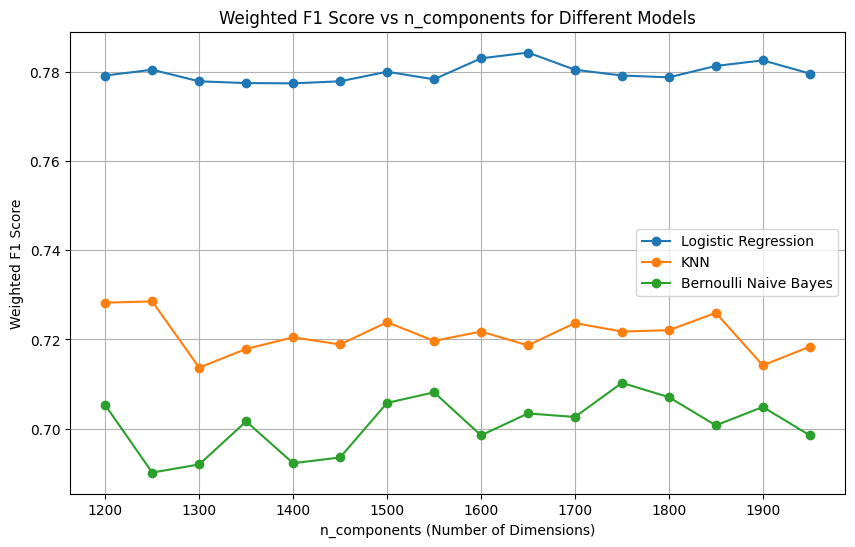

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Données vectorisées (concat1_df) et cible (train_df['cal_réponse_signalement'])
X = concat4_df
y = train_df['cal_réponse_signalement']

# Étape d'encodage des classes cibles
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Séparation des données
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Plage de valeurs pour n_components à tester
n_components_range = list(range(1200,2000 , 50))

# Initialiser les modèles
models = {

    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    # 'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(),
    # 'Decision Tree': DecisionTreeClassifier(),
    'Bernoulli Naive Bayes': BernoulliNB(),
    # 'Multinomial Naive Bayes': MultinomialNB()


}

# Dictionnaire pour stocker les F1 scores
model_scores = {model: [] for model in models.keys()}

# Tester différentes valeurs de n_components
for n_components in n_components_range:
    print(f"Testing n_components={n_components}")
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    X_train_reduced = svd.fit_transform(X_train)
    X_test_reduced = svd.transform(X_test)

    # Évaluer chaque modèle avec les données réduites
    for model_name, model in models.items():
        model.fit(X_train_reduced, y_train)
        y_pred = model.predict(X_test_reduced)
        f1 = f1_score(y_test, y_pred, average='weighted')
        model_scores[model_name].append(f1)

# Visualisation des résultats
plt.figure(figsize=(10, 6))
for model_name, scores in model_scores.items():
    plt.plot(n_components_range, scores, marker='o', label=model_name)

plt.title("Weighted F1 Score vs n_components for Different Models")
plt.xlabel("n_components (Number of Dimensions)")
plt.ylabel("Weighted F1 Score")
plt.legend()
plt.grid()
plt.show()


Nous avons pu tester plusieurs tranches de n_components pour la réduction de dimensions et nous constatons que cette réduction n'aide pas à l'amélioration du F1 score au niveau de la lemmatisation.

## Classification et évaluation des modèles

C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


Model: Bernoulli Naive Bayes
Accuracy: 0.75
Weighted F1 Score: 0.74
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.81      0.87      0.84       741
Rejete (hors specs)       0.52      0.40      0.45       259

           accuracy                           0.75      1000
          macro avg       0.66      0.63      0.64      1000
       weighted avg       0.73      0.75      0.74      1000

Cross-Validation Mean Accuracy: 0.70
--------------------------------------------------


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


Model: Logistic Regression
Accuracy: 0.80
Weighted F1 Score: 0.79
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.83      0.92      0.87       741
Rejete (hors specs)       0.67      0.46      0.54       259

           accuracy                           0.80      1000
          macro avg       0.75      0.69      0.71      1000
       weighted avg       0.79      0.80      0.79      1000

Cross-Validation Mean Accuracy: 0.77
--------------------------------------------------


C:\Users\diall\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1549: UserWarning: Note that pos_label (set to 'pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


Model: K Nearest Neighbors
Accuracy: 0.75
Weighted F1 Score: 0.74
Classification Report:
                     precision    recall  f1-score   support

     Pris en compte       0.81      0.87      0.84       741
Rejete (hors specs)       0.52      0.41      0.46       259

           accuracy                           0.75      1000
          macro avg       0.66      0.64      0.65      1000
       weighted avg       0.73      0.75      0.74      1000

Cross-Validation Mean Accuracy: 0.73
--------------------------------------------------


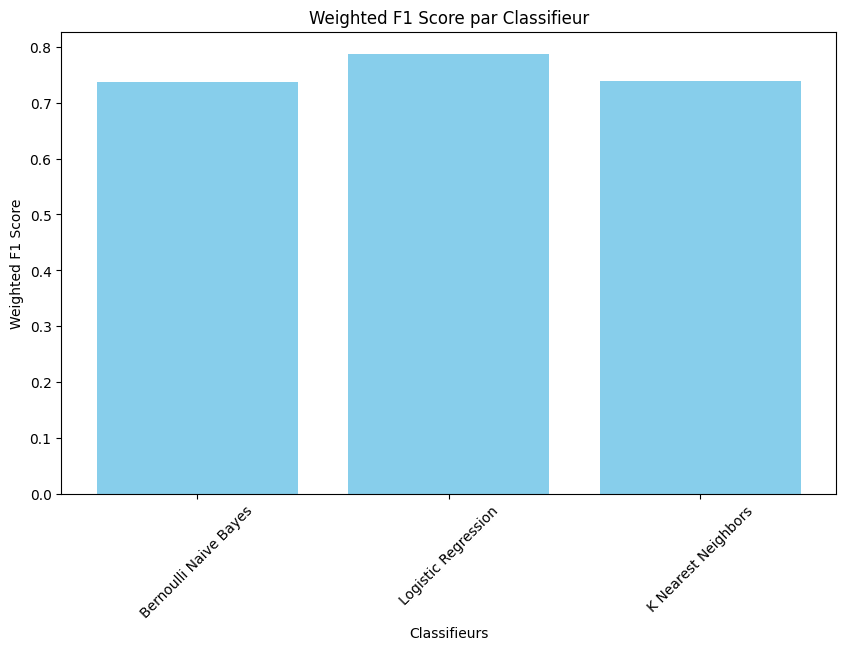

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
import matplotlib.pyplot as plt


X = concat4_df  # Matrice des caractéristiques pré-traitées
y = train_df['cal_réponse_signalement']  # La variable cible

# Division des données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Définition des modèles
models = {
    # 'Multinomial Naive Bayes': MultinomialNB(),
    'Bernoulli Naive Bayes': BernoulliNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'K Nearest Neighbors': KNeighborsClassifier(),
    # 'Decision Tree': DecisionTreeClassifier(),
    # 'Random Forest': RandomForestClassifier()
}

# Dictionnaire pour stocker les scores F1 pondérés
f1_scores = {}

# Évaluation des modèles
for name, model in models.items():
    # Entraînement du modèle
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calcul des métriques
    accuracy = accuracy_score(y_test, y_pred)
    weighted_f1 = f1_score(y_test, y_pred, average='weighted',pos_label='pris en compte')
    report = classification_report(y_test, y_pred, zero_division=0)
    cv_scores = cross_val_score(model, X_train, y_train, cv=10)

    # Stocker le F1 Score pondéré
    f1_scores[name] = weighted_f1

    # Affichage des résultats
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Weighted F1 Score: {weighted_f1:.2f}")
    print(f"Classification Report:\n{report}")
    print(f"Cross-Validation Mean Accuracy: {cv_scores.mean():.2f}")
    print('-' * 50)

# Visualisation des résultats
plt.figure(figsize=(10, 6))
plt.bar(f1_scores.keys(), f1_scores.values(), color='skyblue')
plt.title('Weighted F1 Score par Classifieur')
plt.xlabel('Classifieurs')
plt.ylabel('Weighted F1 Score')
plt.xticks(rotation=45)
plt.show()


À ce stade, nous avons gardé le même cheminement en ajoutant toujours des variables, mais cela n'a eu aucun impact positif sur nos classifieurs. Nous avons aussi testé la réduction de dimensions ainsi que la validation croisée à 10 plis. Notre meilleur classifieur reste toujours à un F1-score de 0,79. Par conséquent, nous allons conserver la même approche mais utiliser la lemmatisation à la place de la racinisation.

Nous allons donc utiliser la lemmatisation tout en gardant les variables de base.

## Importation du jeu de données

Import du jeu de données d'entrainement

In [2]:
import pandas as pd

train_df = pd.read_json('C:/Users/gauth/Desktop/Projet-Code/Python/IA/Projet DATA-Mining/data/train.jsonl', lines=True)
#suppresion des variables jugées inutiles
train_df = train_df.drop(['boamp_id_annonce', 'boamp_parent_annonce', 'cal_fichier_pdf', 'cal_num_signalement','boamp_siret_acheteur','cal_adresse_annonce','boamp_lieu_exec','cal_type_localisation','cal_statut_workflow','boamp_type_organisme'], axis=1)
train_df.head()

,OGC_FID,boamp_theme_boamp,boamp_libelle_annonce,boamp_statut_annonce,boamp_date_fin_de_marche,boamp_num_departement_diffusion,boamp_nom_acheteur,boamp_intitule,cal_theme_signalement,cal_réponse_signalement,cal_mot_rang_1,cal_mot_rang_2,cal_date_traitement,cal_num_departement_exec,cal_siren_epci,cal_insee_commune_exec,cal_nom_commune_exec,texte_annonce
0,9723,Espaces verts,Avis de marché,INITIAL,2024-02-02,31,TOULOUSE METROPOLE,Travaux d'aménagement de l'île du Ramier à Tou...,Route,Pris en compte,travaux,aménagement,2023-12-22,31,243100518,31555,TOULOUSE,Avis n° 23-177335\n \nAttention : les informa...
1,10502,Station d'épuration (travaux),Avis de marché,INITIAL,2024-08-08,09,Syndicat Mixte Départemental de l'Eau et de l'...,Travaux de construction de la nouvelle station...,Points d'intérêt,Pris en compte,nouvelle,station,2024-05-30,9,,09332,VERNIOLLE,1/3\nAvis de marché\nAttention : les informat...
2,10900,Voirie et réseaux divers,Rectificatif,RECTIFICATIF,2024-08-23,33,Bordeaux Métropole,"Aménagement de la place de la Renaudel, rues ...",Route,Pris en compte,aménagement,place,2024-08-14,33,243300316,33063,BORDEAUX,1/1\nAvis rectificatif\nAttention : les infor...
3,779,"Prestations de services, Délégation de service...",Avis de marché,INITIAL,2024-04-16,75,Ville de Paris,Rénovation du parc de stationnement St Martin ...,Points d'intérêt,Rejete (hors specs),transformation,parc,2023-12-29,75,,75056,PARIS,Avis n° 23-179664\n \nAttention : les informa...
4,5614,Génie civil,Avis de marché,INITIAL,2024-07-11,43,Département de la Haute-Loire,Rd12 - Reconstruction Du Pont Sur La Loire A B...,Route,Pris en compte,reconstruction,pont,2024-06-14,43,,43020,BAS EN BASSET,1/2\nAvis de marché\nAttention : les informat...


In [3]:
import subprocess

# Commande à exécuter
command = "python -m spacy download fr_core_news_sm"

# Exécuter la commande
subprocess.run(command, shell=True)


CompletedProcess(args='python -m spacy download fr_core_news_sm', returncode=0)

## Pré-traitement : Lemmatisation

In [4]:
import pandas as pd
import re
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
import nltk
import spacy

# Télécharger les stopwords français si nécessaire
nltk.download('stopwords')


# Initialiser le modèle spaCy pour la lemmatisation
nlp = spacy.load('fr_core_news_sm')

# Définir les colonnes textuelles et catégorielles
text_columns = ['boamp_theme_boamp', 'boamp_intitule', 'texte_annonce']
categorical_columns = ['cal_mot_rang_1', 'cal_mot_rang_2', 'boamp_libelle_annonce', 'boamp_statut_annonce', 'cal_theme_signalement', 'boamp_num_departement_diffusion']

# Ajouter des mots vides supplémentaires
additional_stop_words = set([
    "de","la", "le", "les",
    "des", "du", "un", "une", "en", "et",
    "à", "au", "aux", "par", "pour", "sur",
    "dans", "avec", "ce", "cette", "ces", "mon",
    "ma", "mes", "ton", "ta", "tes", "son", "sa",
    "ses", "notre", "nos", "votre", "vos", "leur",
    "leurs", "ne", "pas", "plus", "moins", "ou",
    "si", "oui", "non", "je", "tu", "il", "elle",
    "nous", "vous", "ils", "elles", "me", "te",
    "se", "moi", "toi", "lui", "leur", "y", "en",
    "d'", "l'","s'", "c'", "n'", "j'", "t'", "m'", "qu'", "l'"
])

stop_words = set(stopwords.words("french")).union(additional_stop_words)

# Fonction de nettoyage et de lemmatisation des textes
def clean_text(text):
    if isinstance(text, float):
        return ''

    # Suppression des caractères spéciaux et de la ponctuation (conservation des lettres avec accents et apostrophes)
    text = re.sub(r'[^\w\s\']', '', text)

    # Conversion en minuscule
    text = text.lower()

    # Traitement du texte avec spaCy pour lemmatisation
    doc = nlp(text)

    # Suppression des mots vides
    lemmatized_tokens = [token.lemma_ for token in doc if token.text not in stop_words]

    # Joindre les tokens en une seule chaîne
    cleaned_text = ' '.join(lemmatized_tokens)

    return cleaned_text

# Étape 1 : Appliquer le nettoyage et la lemmatisation aux colonnes textuelles
for col in text_columns:
    train_df[col] = train_df[col].apply(lambda x: clean_text(x))

# Étape 2 : Vectorisation des colonnes textuelles avec TF-IDF (sans réduction des dimensions)
vectorized_dfs = {}
for col in text_columns:
    vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))  # Inclut unigrams et bigrams
    vectorized_df = pd.DataFrame(
        vectorizer.fit_transform(train_df[col]).toarray(),
        columns=[f"{col}_{feat}" for feat in vectorizer.get_feature_names_out()]
    )
    vectorized_dfs[col] = vectorized_df

# Étape 3 : Encodage des colonnes catégorielles avec OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
categorical_encoded = pd.DataFrame(
    encoder.fit_transform(train_df[categorical_columns]),
    columns=encoder.get_feature_names_out(categorical_columns)
)

# Étape 4 : Concaténer toutes les colonnes vectorisées et encodées
final_train_df = pd.concat([*vectorized_dfs.values(), categorical_encoded], axis=1)

# Affichage d'un échantillon des données finales
print(final_train_df.head())


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gauth\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   boamp_theme_boamp_abonnement  boamp_theme_boamp_abonnemer  \
0                           0.0                          0.0   
1                           0.0                          0.0   
2                           0.0                          0.0   
3                           0.0                          0.0   
4                           0.0                          0.0   

   boamp_theme_boamp_abonnemer equipemer  boamp_theme_boamp_abri  \
0                                    0.0                     0.0   
1                                    0.0                     0.0   
2                                    0.0                     0.0   
3                                    0.0                     0.0   
4                                    0.0                     0.0   

   boamp_theme_boamp_abri abonnement  boamp_theme_boamp_abri bardage  \
0                                0.0                             0.0   
1                                0.0                          

In [5]:
# Transformation de la colonne cible
train_df['cal_réponse_signalement'] = train_df['cal_réponse_signalement'].map({'Pris en compte': 1, 'Rejete (hors specs)': 0})
print(train_df['cal_réponse_signalement'])

0       1
1       1
2       1
3       0
4       1
       ..
4995    1
4996    1
4997    1
4998    1
4999    0
Name: cal_réponse_signalement, Length: 5000, dtype: int64


## Classification et évaluation des modèles

## Rechercher les meilleurs Hyperparamètres pour le modèle de Régression logistique

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

# Utiliser final_df sans réduction de dimension comme ensemble de données
X = final_train_df  # Les données vectorisées sans réduction de dimension
y = train_df['cal_réponse_signalement']  # Variable cible

# Assurer que les dimensions de X et y correspondent
assert X.shape[0] == y.shape[0], "Les dimensions de X et y ne correspondent pas"

# Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Définition de l'espace des hyperparamètres pour la régression logistique
param_grid = {
    'C': [1],  # Essai de différentes valeurs pour le paramètre de régularisation
    'solver': ['liblinear'],  # Différents solveurs possibles pour optimiser
    'penalty': ['l2'],  # 'l1' est disponible uniquement pour le solver 'liblinear'
    'max_iter': [100],  # Tester différents nombres d'itérations
    'dual': [False],  # Formulation duale
    'fit_intercept': [True],  # Ajouter un terme de biais au modèle
    'class_weight': [None],  # Gérer les déséquilibres des classes
    'tol': [0.01],  # Tolérance pour le critère d'arrêt
    'warm_start': [True]  # Utiliser la solution de l'entraînement précédent
}



# Initialisation du modèle de régression logistique
log_reg = LogisticRegression()

# Utilisation de GridSearchCV pour la recherche d'hyperparamètres
grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=10, scoring='f1_weighted', n_jobs=-1, verbose=3)

# Exécution de GridSearchCV
grid_search.fit(X_train, y_train)

# Affichage des meilleurs hyperparamètres
print("Meilleurs hyperparamètres :", grid_search.best_params_)

# Entraînement du modèle avec les meilleurs hyperparamètres
best_log_reg = grid_search.best_estimator_
best_log_reg.fit(X_train, y_train)
y_pred = best_log_reg.predict(X_test)

# Calcul du weighted F1 score et affichage du rapport de classification
weighted_f1 = f1_score(y_test, y_pred, average='weighted', pos_label="Pris en compte")
report = classification_report(y_test, y_pred, zero_division=0)

print("\nOptimisation de la régression logistique :")
print(f"Weighted F1 Score après optimisation : {weighted_f1:.3f}")
print("Classification Report :\n", report)

Fitting 10 folds for each of 1 candidates, totalling 10 fits
Meilleurs hyperparamètres : {'C': 1, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear', 'tol': 0.01, 'warm_start': True}

Optimisation de la régression logistique :
Weighted F1 Score après optimisation : 0.793
Classification Report :
               precision    recall  f1-score   support

           0       0.69      0.46      0.55       259
           1       0.83      0.93      0.88       741

    accuracy                           0.81      1000
   macro avg       0.76      0.69      0.71      1000
weighted avg       0.79      0.81      0.79      1000



C:\Users\gauth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1583: UserWarning: Note that pos_label (set to 'Pris en compte') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


## Conclusion Finale

En conclusion, après avoir exploré et comparé deux approches principales pour le traitement des données textuelles – la racinisation et la lemmatisation – il apparaît que la lemmatisation associée à un comptage pondéré offre les meilleurs résultats. Cette méthode, intégrée dans un modèle de régression logistique optimisé avec une validation croisée à 10 plis, a permis d'obtenir des performances légèrement supérieures, bien que la racinisation ait également montré une certaine efficacité. Finalement, Le meilleur F1 score que nous ayons obtenu est de 0,793 avec un modèle de régression logistique utilisant les meilleurs hyperparamètres. Ainsi, la lématisation se démarque comme l’approche privilégiée pour ce projet, combinant précision et cohérence dans les prédictions.

## Approche utilisée

En explorant le traitement textuel par la lématisation, une approche efficace a été mise en œuvre en nettoyant les textes, en appliquant un lématiseur pour réduire les mots à leurs formes simplifiées, et en utilisant un comptage pondéré via la vectorisation TF-IDF incluant unigrams et bigrams. Cette méthode a permis de capturer les informations essentielles des données tout en préservant leur spécificité contextuelle.

Par la suite, l'intégration de ces données dans un modèle de régression logistique a démontré des performances remarquables. Grâce à une recherche exhaustive des hyperparamètres avec une validation croisée à 10 plis, les meilleurs paramètres ont été identifiés :

- C = 1,
- class_weight= None,
- dual= False,
- fit_intercept= True,
- max_iter= 100,
- penalty= 'l2',
- solver= 'liblinear',
- tol= 0.01,
- warm_start= True


Ce modèle optimisé a permis d’atteindre un score F1 pondéré de 0,79, soulignant ainsi sa capacité à gérer efficacement le déséquilibre des classes dans la variable cible.

Ces résultats montrent que l’approche combinant lématisation et optimisation de la régression logistique est bien adaptée à ce projet. Elle se distingue par sa capacité à extraire et exploiter des informations pertinentes tout en maintenant un bon équilibre entre précision et généralisation.